# Multi-Video Analysis — 28 debates × 8 candidates

**Structure**
- **Part I — Audio-only**
- **Part II — Audio ↔ Visual** 
- **Part III — New findings** across all debates: candidate emotion
  profiles for all debates, poll correlation, opponent effect, joint dimensionality reduction.

## Setup

In [36]:
import sys, os
sys.path.insert(0, 'multivideo_analysis')
sys.path.insert(0, '../multivideo_analysis')
import os, sys, re, math, unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr, spearmanr, wilcoxon
from wordcloud import WordCloud

from pipelines import (build_labeled_audio, build_labels_all, build_seg_all,
                       CANDIDATES, NON_REDUNDANT, CAND_COLOR, extract_candidates)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
FEATURES_DIR = '../Project_Features'

In [37]:
# ----- Audio data -----
data = build_labeled_audio()
debate_videos = sorted(v for v in data['video'].unique() if 'vs' in v)

candidates_data = data[
    data['video'].isin(debate_videos) &
    data['speaker'].isin(CANDIDATES)
].copy()
candidates = CANDIDATES
color_map  = CAND_COLOR  

KEY_FEATURES = [
    'meanF0Hz','stdevF0Hz','HNR','localJitter','localShimmer',
    'speechrate','articulationrate','npause','asd','f1_mean','f2_mean','fdisp',
]

print(f'{len(data)} audio segments | {len(debate_videos)} debates')
print(f'Candidate segments: {len(candidates_data)}')

build_labeled_audio: 2656 segments | 28 debates | 9 unique speakers
2656 audio segments | 28 debates
Candidate segments: 2107


In [38]:
# ----- Silhouette quality scores — needed for transcript cells later -----
quality_scores = {}
for v in debate_videos:
    E = np.stack(data[data['video'] == v]['speak_embeddings'].values)
    lbl = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(E)
    quality_scores[v] = silhouette_score(E, lbl, metric='cosine')
print(f'Silhouette scores computed for {len(quality_scores)} debates.')
print(f'Mean silhouette: {np.mean(list(quality_scores.values())):.3f}')

Silhouette scores computed for 28 debates.
Mean silhouette: 0.548


In [39]:
# ----- seg_all: visual pipeline required (slow first run, cached after) -----
SEG_ALL_CACHE = 'seg_all.pkl'
LABELS_CACHE  = 'labels_all.pkl'

if os.path.exists(SEG_ALL_CACHE):
    seg_all    = pd.read_pickle(SEG_ALL_CACHE)
    labels_all = pd.read_pickle(LABELS_CACHE) if os.path.exists(LABELS_CACHE) else None
    print(f'Loaded seg_all from cache: {seg_all.shape}')
else:
    print('Building labels_all (visual GMM pipeline, ~15 min)...')
    labels_all = build_labels_all(debate_videos, data)
    labels_all.to_pickle(LABELS_CACHE)
    print('Building seg_all (frame-audio join + aggregation)...')
    seg_all = build_seg_all(debate_videos, data, labels_all)
    seg_all.to_pickle(SEG_ALL_CACHE)
    print(f'seg_all saved: {seg_all.shape}')

emotion_cols      = [c for c in seg_all.columns if c.startswith('prob_')]
pose_feature_cols = ['shoulder_slope','body_openness','head_tilt','wrist_height','torso_height']
seg_cands         = seg_all[seg_all['final_name'].isin(CANDIDATES)].copy()

print(f'seg_all shape: {seg_all.shape}')
print(f'Candidate segments in seg_all: {len(seg_cands)}')
print(f'Emotion cols: {emotion_cols}')
print(f'Pose cols:    {pose_feature_cols}')

Loaded seg_all from cache: (2128, 29)
seg_all shape: (2128, 29)
Candidate segments in seg_all: 1766
Emotion cols: ['prob_Anger', 'prob_Contempt', 'prob_Disgust', 'prob_Fear', 'prob_Happiness', 'prob_Neutral', 'prob_Sadness', 'prob_Surprise']
Pose cols:    ['shoulder_slope', 'body_openness', 'head_tilt', 'wrist_height', 'torso_height']


---
# Part I — Audio-only multi-video analysis

These sections use only acoustic features and speaker embeddings (`data` from
`build_labeled_audio()`), without any visual information. They mirror the content
that was in `labeling_audio/correlations_audio.ipynb` Parts VI, VII, and VIII.

## I.A — Acoustic feature landscape across all 28 debates

Global distribution and correlation structure of the 12 key acoustic features,
pooled over all ~2600 segments from all debates.

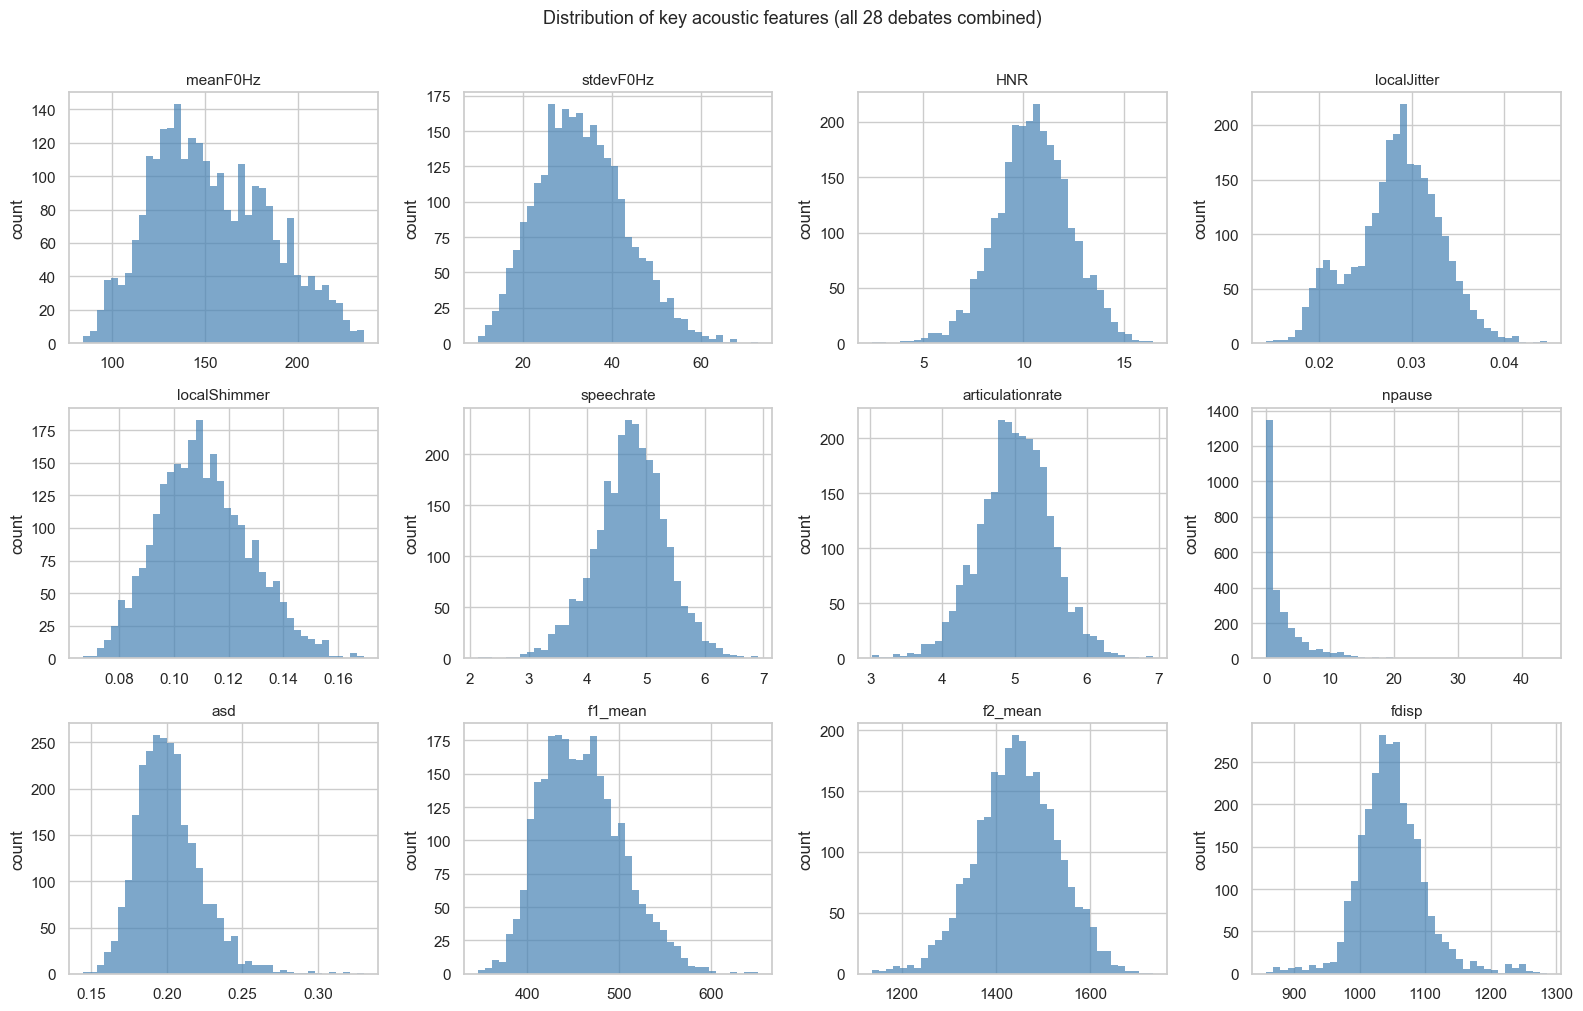

In [40]:
# Feature distributions — one histogram per key feature
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(KEY_FEATURES):
    axes[i].hist(data[col].dropna(), bins=40, color='steelblue', alpha=0.7, edgecolor='none')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('count')
plt.suptitle('Distribution of key acoustic features (all 28 debates combined)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

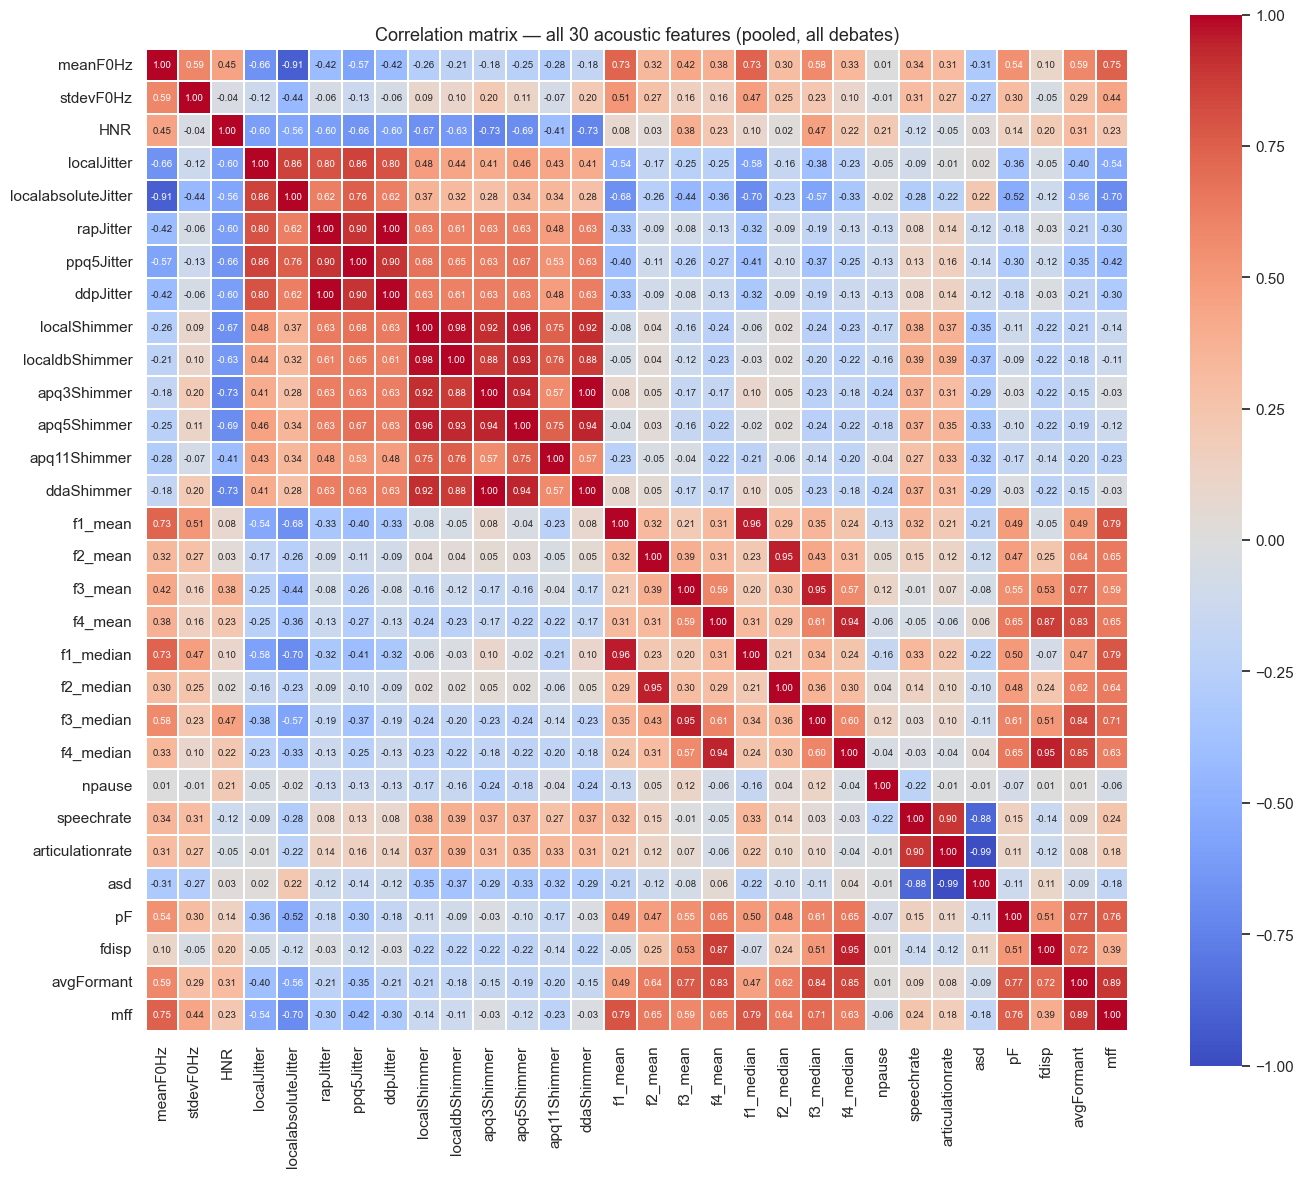

,feature_a,feature_b,r
0,ddaShimmer,apq3Shimmer,1.000
1,articulationrate,asd,-0.986
2,localdbShimmer,localShimmer,0.977
3,localShimmer,apq5Shimmer,0.959
4,f1_median,f1_mean,0.956
...,...,...,...
130,meanF0Hz,ddpJitter,-0.416
131,HNR,apq11Shimmer,-0.412
132,f1_median,ppq5Jitter,-0.408
133,localJitter,apq3Shimmer,0.406


In [41]:
# Full feature correlation matrix — reveals redundant groups
scalar_cols = [c for c in data.columns if c not in
               ['video','time stamp','duration','speak_embeddings','cluster_k3','speaker','party']]
corr = data[scalar_cols].corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.3, annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation matrix — all 30 acoustic features (pooled, all debates)', fontsize=13)
plt.tight_layout()
plt.show()

# Top pairs (|r| > 0.4, excluding self-correlations)
seen, rows = set(), []
for (a, b), v in corr.abs().unstack().sort_values(ascending=False).items():
    key = tuple(sorted([a, b]))
    if key not in seen and v < 1.0 and v > 0.4:
        seen.add(key); rows.append({'feature_a': a, 'feature_b': b, 'r': round(corr.loc[a,b],3)})
display(pd.DataFrame(rows))

## I.B — Per-candidate acoustic profiles

How does each candidate's voice differ from the others?
We look at speaking time, turn length, key features, and the normalized profile heatmap.

**Caveat:** speaker labels for Tier-2 debates (Ventura, Pinto, lower silhouette) are
less reliable; treat those two candidates' profiles with some caution.

Segments per candidate:
speaker
Marques_Mendes       336
Gouveia_Melo         330
Seguro               293
Cotrim_Figueiredo    281
Martins              260
Filipe               242
Ventura              195
Pinto                170



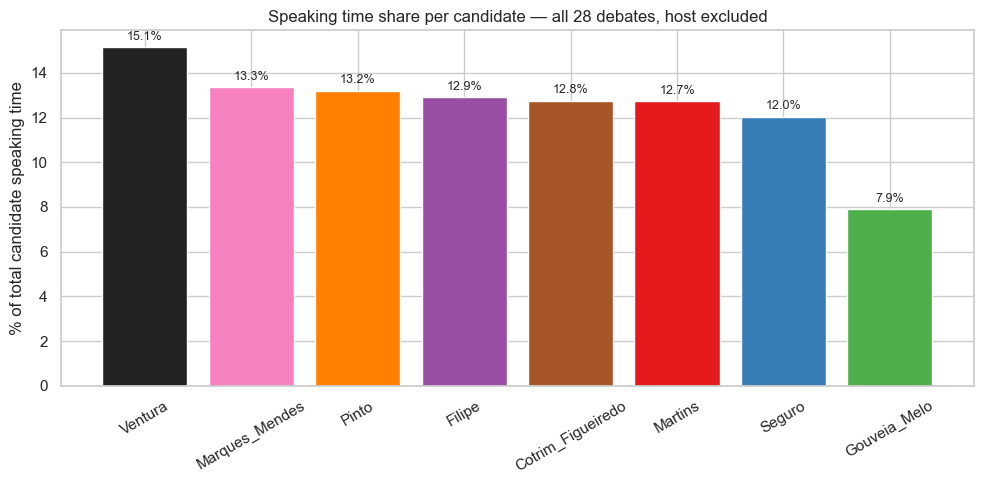

In [42]:
# Speaking time and segment counts
print('Segments per candidate:')
print(candidates_data['speaker'].value_counts().to_string())
print()
total_time_all = candidates_data['duration'].sum()
time_share = (candidates_data.groupby('speaker')['duration'].sum()
              / total_time_all * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(time_share.index, time_share.values,
              color=[color_map.get(c,'grey') for c in time_share.index], edgecolor='white')
for bar, val in zip(bars, time_share.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('% of total candidate speaking time')
ax.set_title('Speaking time share per candidate — all 28 debates, host excluded', fontsize=12)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

/var/folders/5g/t8kckpys61zdtmy3jx9lt0z00000gn/T/ipykernel_4972/2481112501.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=candidates_data, x='speaker', y='duration',


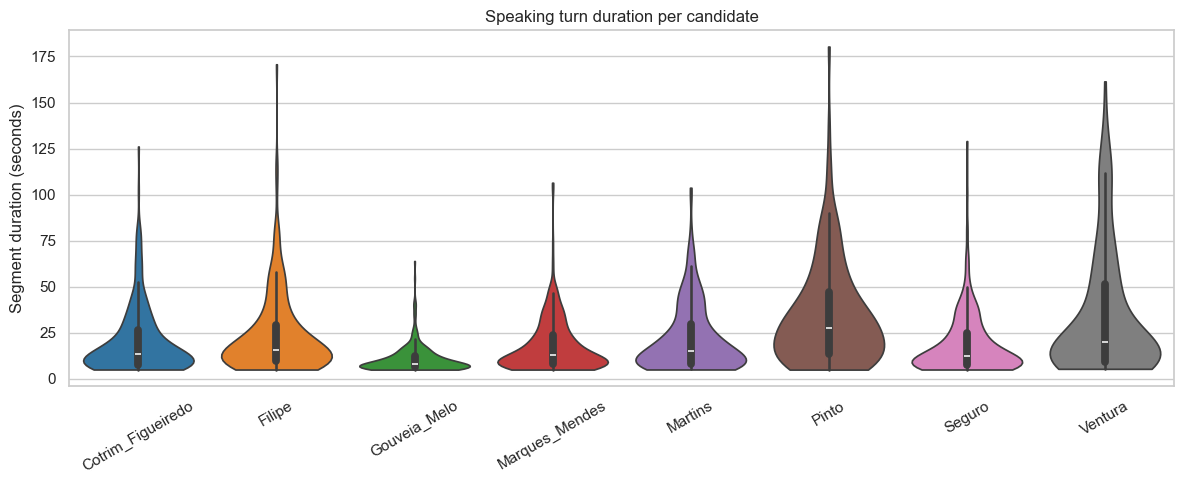

/var/folders/5g/t8kckpys61zdtmy3jx9lt0z00000gn/T/ipykernel_4972/2481112501.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='speaker', y=col, ax=axes[i],
/var/folders/5g/t8kckpys61zdtmy3jx9lt0z00000gn/T/ipykernel_4972/2481112501.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='speaker', y=col, ax=axes[i],
/var/folders/5g/t8kckpys61zdtmy3jx9lt0z00000gn/T/ipykernel_4972/2481112501.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='speaker', y=col, ax=axes[i],
/var/folders/5g/t8k

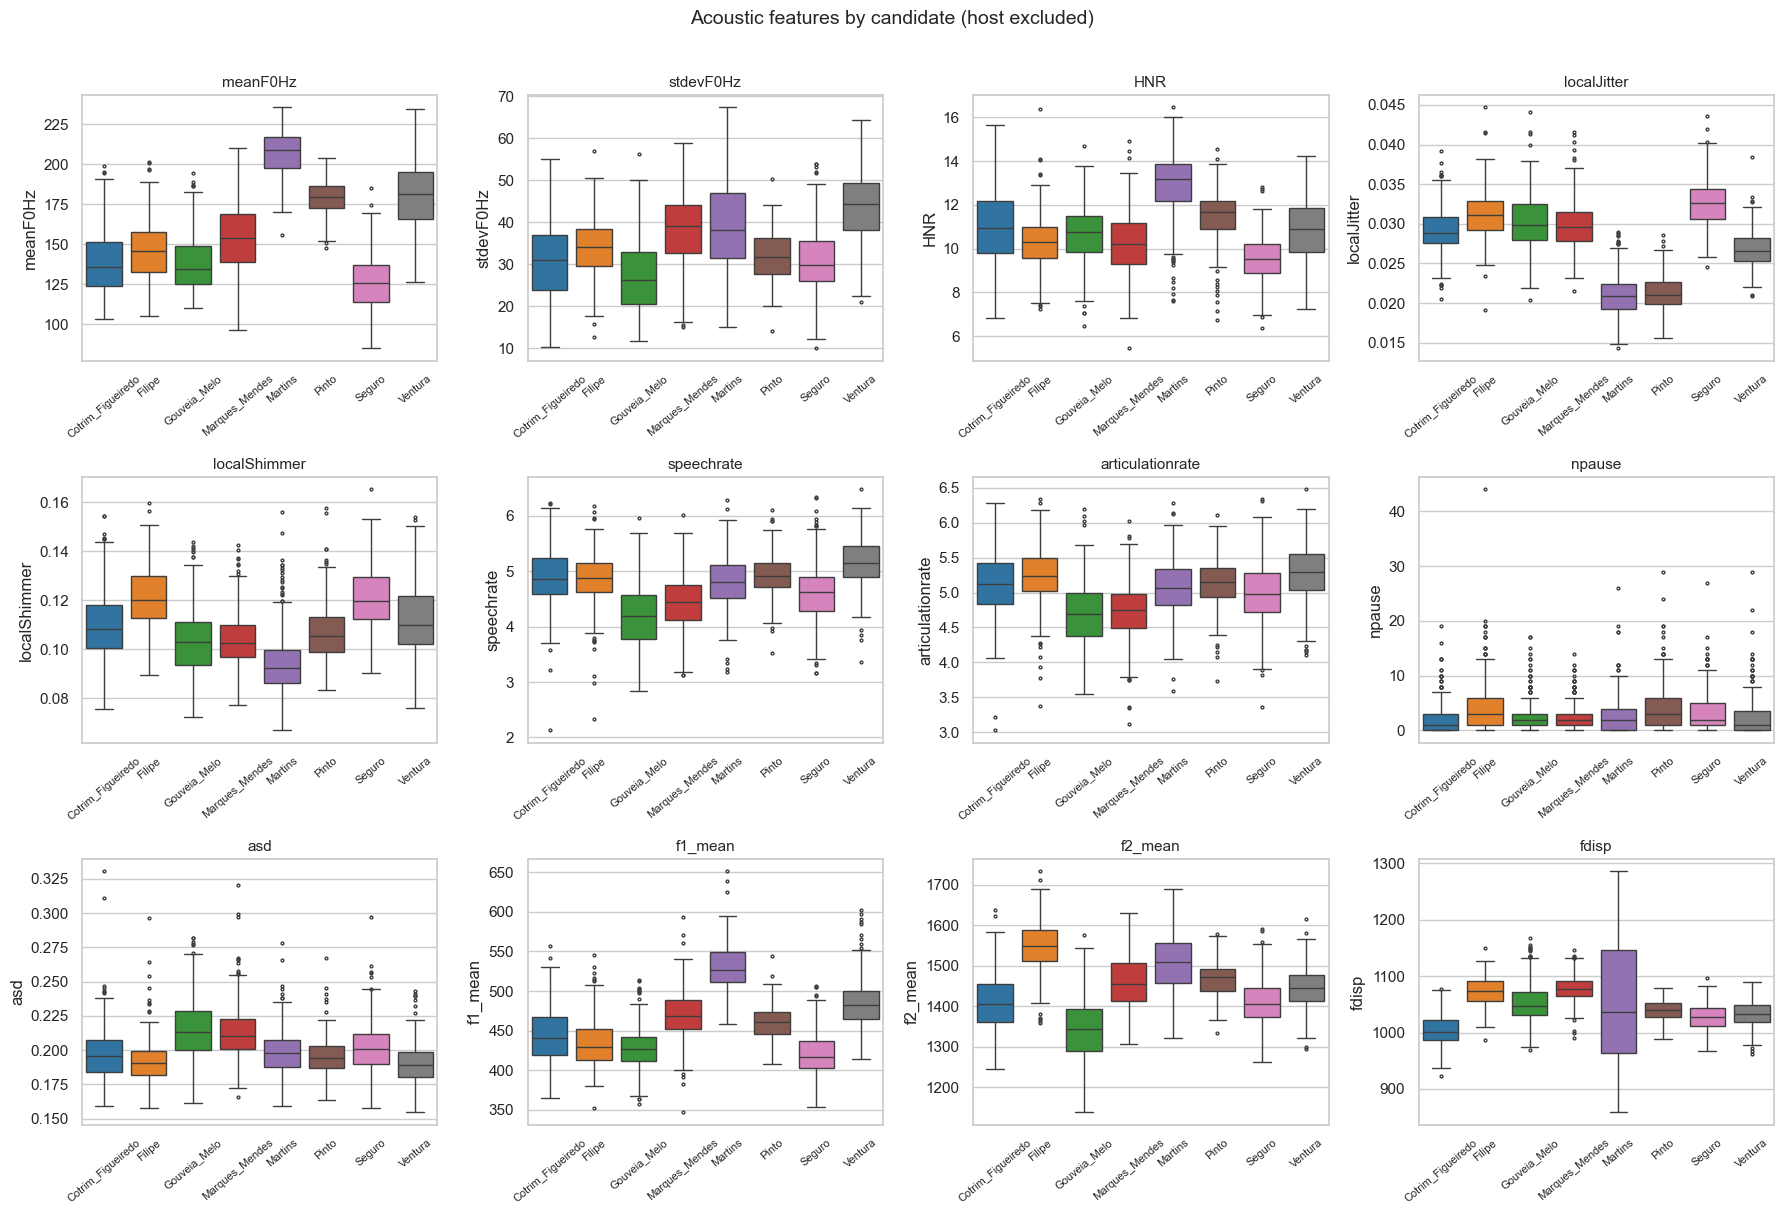

In [43]:
# Turn length distributions (violin) and box plots of KEY_FEATURES
fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(data=candidates_data, x='speaker', y='duration',
               order=candidates, palette='tab10', ax=ax, cut=0)
ax.set_xlabel(''); ax.set_ylabel('Segment duration (seconds)')
ax.set_title('Speaking turn duration per candidate', fontsize=12)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(3, 4, figsize=(18, 12)); axes = axes.flatten()
for i, col in enumerate(KEY_FEATURES):
    plot_data = candidates_data[['speaker', col]].dropna()
    sns.boxplot(data=plot_data, x='speaker', y=col, ax=axes[i],
                palette='tab10', order=candidates, fliersize=2)
    axes[i].set_title(col, fontsize=11); axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=40, labelsize=8)
plt.suptitle('Acoustic features by candidate (host excluded)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

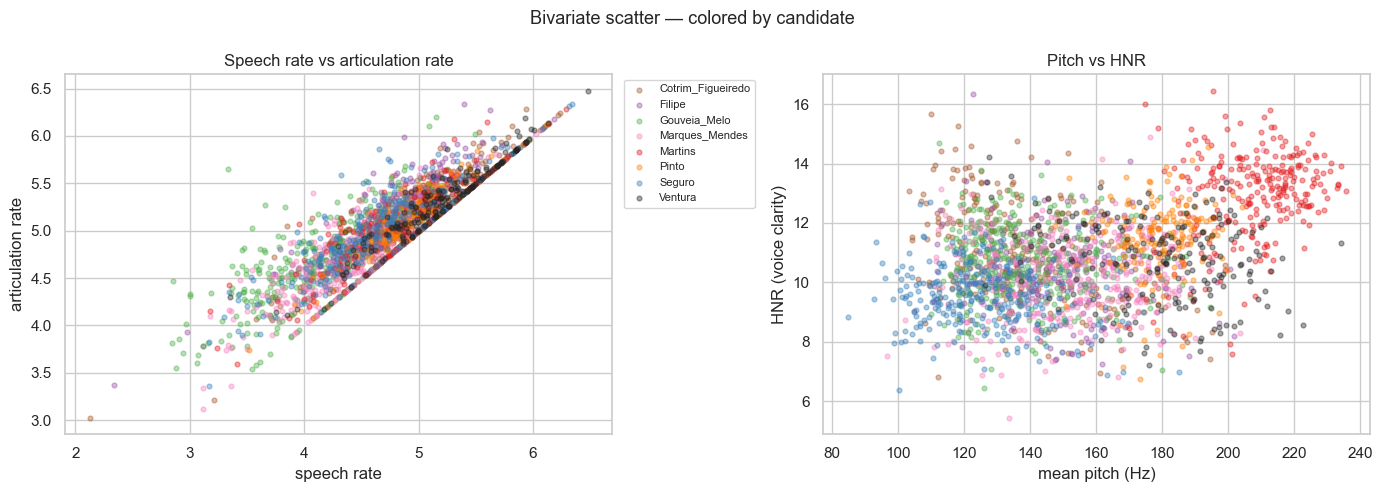

In [44]:
# Bivariate scatters: speech rate vs articulation, pitch vs HNR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cand in candidates:
    sub = candidates_data[candidates_data['speaker'] == cand]
    axes[0].scatter(sub['speechrate'], sub['articulationrate'],
                    alpha=0.4, s=12, label=cand, color=color_map.get(cand,'grey'))
    axes[1].scatter(sub['meanF0Hz'], sub['HNR'],
                    alpha=0.4, s=12, label=cand, color=color_map.get(cand,'grey'))
axes[0].set_xlabel('speech rate'); axes[0].set_ylabel('articulation rate')
axes[0].set_title('Speech rate vs articulation rate')
axes[0].legend(fontsize=8, bbox_to_anchor=(1.01,1), loc='upper left')
axes[1].set_xlabel('mean pitch (Hz)'); axes[1].set_ylabel('HNR (voice clarity)')
axes[1].set_title('Pitch vs HNR')
plt.suptitle('Bivariate scatter — colored by candidate', fontsize=13)
plt.tight_layout(); plt.show()

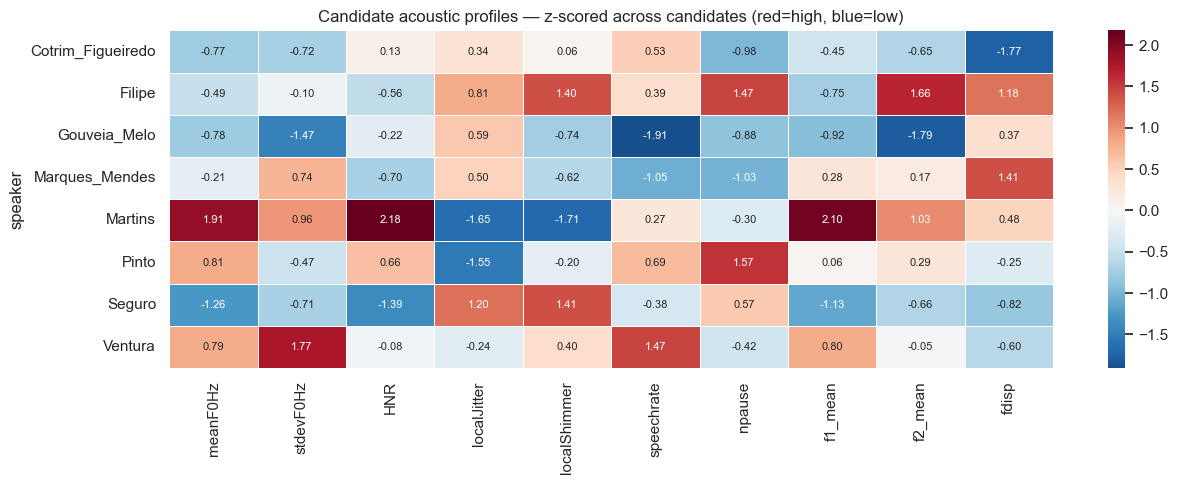

,meanF0Hz,stdevF0Hz,HNR,localJitter,localShimmer,speechrate,articulationrate,npause,asd,f1_mean,f2_mean,fdisp
speaker,,,,,,,,,,,,
Cotrim_Figueiredo,138.901,30.824,10.994,0.029,0.110,4.887,5.114,2.370,0.197,444.294,1409.672,1004.954
Filipe,146.061,33.927,10.335,0.031,0.121,4.845,5.221,4.260,0.193,434.131,1547.514,1072.432
Gouveia_Melo,138.577,27.107,10.657,0.030,0.103,4.188,4.703,2.452,0.215,428.329,1341.260,1054.000
Marques_Mendes,153.167,38.163,10.204,0.030,0.104,4.433,4.729,2.333,0.213,468.822,1458.663,1077.717
Martins,207.531,39.283,12.921,0.021,0.095,4.811,5.063,2.896,0.199,529.677,1509.766,1056.463
Pinto,179.363,32.092,11.487,0.021,0.108,4.931,5.143,4.335,0.195,461.455,1465.834,1039.732
Seguro,126.446,30.907,9.554,0.033,0.121,4.626,4.998,3.563,0.202,421.421,1409.298,1026.633
Ventura,178.980,43.306,10.791,0.027,0.113,5.154,5.287,2.800,0.190,486.098,1445.264,1031.651


In [45]:
# Normalized acoustic profile heatmap — who is high/low on each feature?
profile_nr = candidates_data.groupby('speaker')[NON_REDUNDANT].mean()
profile_norm = pd.DataFrame(
    StandardScaler().fit_transform(profile_nr),
    index=profile_nr.index, columns=profile_nr.columns
)
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(profile_norm, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.4, annot_kws={'size': 8}, ax=ax)
ax.set_title('Candidate acoustic profiles — z-scored across candidates (red=high, blue=low)', fontsize=12)
plt.tight_layout(); plt.show()

# Mean values table
display(candidates_data.groupby('speaker')[KEY_FEATURES].mean().round(3))

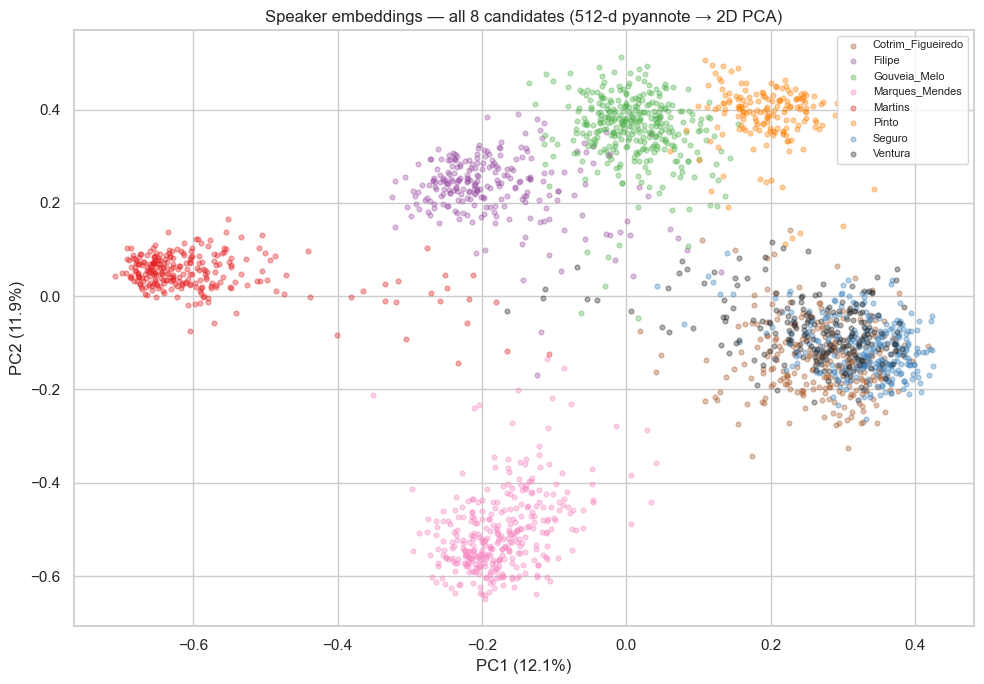

In [46]:
# PCA of speaker embeddings — do the 8 candidates separate in 512-d space?
emb_matrix = np.stack(candidates_data['speak_embeddings'].values)
pca_emb = PCA(n_components=2, random_state=42)
emb_2d  = pca_emb.fit_transform(emb_matrix)
v1, v2  = pca_emb.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(10, 7))
for cand in candidates:
    mask = candidates_data['speaker'].values == cand
    ax.scatter(emb_2d[mask,0], emb_2d[mask,1],
               label=cand, alpha=0.35, s=12, color=color_map.get(cand,'grey'))
ax.set_title('Speaker embeddings — all 8 candidates (512-d pyannote → 2D PCA)', fontsize=12)
ax.set_xlabel(f'PC1 ({v1:.1f}%)'); ax.set_ylabel(f'PC2 ({v2:.1f}%)')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## I.C — Candidate voice consistency across debates

How stable is each candidate's speaker embedding across their 7 appearances?
Low distance to own global centroid → consistent acoustic identity across opponents and dates.

/var/folders/5g/t8kckpys61zdtmy3jx9lt0z00000gn/T/ipykernel_4972/1910643273.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=consistency, x='speaker', y=col, order=order,
/var/folders/5g/t8kckpys61zdtmy3jx9lt0z00000gn/T/ipykernel_4972/1910643273.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=consistency, x='speaker', y=col, order=order,


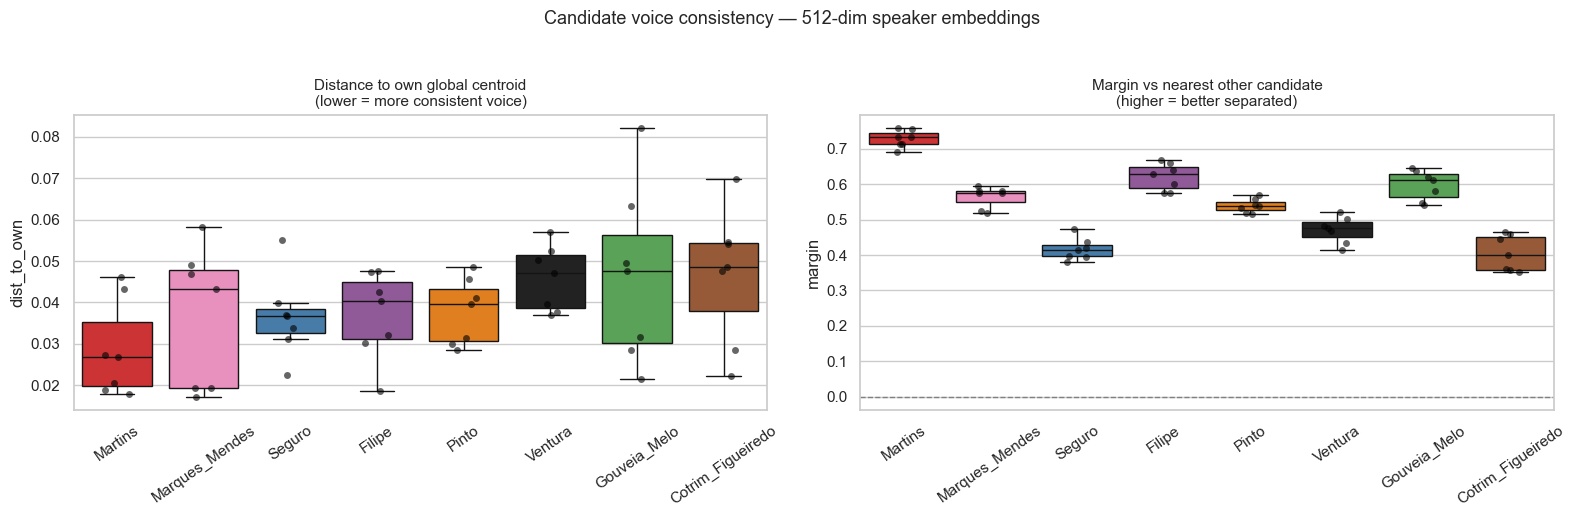

,debates,mean_dist,mean_margin
speaker,,,
Martins,7,0.0287,0.7282
Marques_Mendes,7,0.0361,0.5639
Seguro,7,0.0366,0.4171
Filipe,7,0.0370,0.6211
Pinto,7,0.0378,0.5394
Ventura,7,0.0459,0.4711
Gouveia_Melo,7,0.0463,0.5976
Cotrim_Figueiredo,7,0.0465,0.4054


In [47]:
# Per-candidate, per-debate centroid; then compare within vs between
cand_debate_rows = []
for (speaker, video), grp in candidates_data.groupby(['speaker','video']):
    E = np.stack(grp['speak_embeddings'].values)
    cand_debate_rows.append({'speaker':speaker,'video':video,
                              'n_segments':len(grp),'total_duration':grp['duration'].sum(),
                              'centroid':E.mean(axis=0)})

cdt = pd.DataFrame(cand_debate_rows)
global_c = cdt.groupby('speaker')['centroid'].apply(
    lambda s: np.mean(np.stack(s.values), axis=0))

per_rows, within_rows = [], []
for speaker, sub in cdt.groupby('speaker'):
    cents    = np.stack(sub['centroid'].values)
    own_c    = global_c[speaker]
    d_own    = cdist(cents, own_c[None,:], metric='cosine').ravel()
    others   = [c for c in global_c.index if c != speaker]
    d_oth    = cdist(cents, np.stack(global_c[others].values), metric='cosine')
    tmp      = sub[['speaker','video','n_segments','total_duration']].copy()
    tmp['dist_to_own']      = d_own
    tmp['nearest_other']    = d_oth.min(axis=1)
    tmp['margin']           = tmp['nearest_other'] - tmp['dist_to_own']
    per_rows.append(tmp)
    if len(cents) > 1:
        pw = cdist(cents, cents, metric='cosine')
        iu = np.triu_indices_from(pw, k=1)
        for d in pw[iu]:
            within_rows.append({'speaker':speaker,'distance':d,'kind':'within-candidate'})

consistency = pd.concat(per_rows, ignore_index=True)
order = consistency.groupby('speaker')['dist_to_own'].mean().sort_values().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, col, title in zip(axes,
    ['dist_to_own','margin'],
    ['Distance to own global centroid\n(lower = more consistent voice)',
     'Margin vs nearest other candidate\n(higher = better separated)']):
    sns.boxplot(data=consistency, x='speaker', y=col, order=order,
                palette=[color_map.get(c,'grey') for c in order], ax=ax, fliersize=0)
    sns.stripplot(data=consistency, x='speaker', y=col, order=order,
                  ax=ax, color='black', alpha=0.6, size=5, jitter=0.15)
    ax.set_title(title, fontsize=11); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)
if any(within_rows):
    axes[1].axhline(0, color='gray', ls='--', lw=1)
plt.suptitle('Candidate voice consistency — 512-dim speaker embeddings', fontsize=13, y=1.03)
plt.tight_layout(); plt.show()

display(consistency.groupby('speaker').agg(
    debates=('video','nunique'),
    mean_dist=('dist_to_own','mean'),
    mean_margin=('margin','mean')
).round(4).sort_values('mean_dist'))

## I.D — Transcript analysis across all debates

Lexical analysis of what each candidate actually says: bigrams, richness,
word clouds, and semantic similarity across their debates using 4096-dim EuroLLM
transcript embeddings.

In [48]:
# Load all speech pkls (debates only)
speech_files = [f for f in os.listdir(FEATURES_DIR) if f.endswith('_speech.pkl')]
sdfs = []
for f in speech_files:
    df = pd.read_pickle(os.path.join(FEATURES_DIR, f))
    df['video'] = f.replace('_speech.pkl','')
    sdfs.append(df)
data_speech = pd.concat(sdfs, ignore_index=True)
data_speech['word_count']   = data_speech['transcript'].apply(lambda t: len(str(t).split()) if pd.notnull(t) else 0)
data_speech['words_per_sec'] = data_speech['word_count'] / data_speech['duration']

# Merge speaker labels
ts_col = 'timestamp' if 'timestamp' in data_speech.columns else 'time stamp'
speech_labeled = data_speech.merge(
    data[['video','time stamp','speaker','party']].rename(columns={'time stamp':ts_col}),
    on=['video',ts_col], how='left')

speech_debates = speech_labeled[speech_labeled['video'].isin(debate_videos)].copy()
print(f'Speech segments: {len(speech_debates)} | labeled: {speech_debates["speaker"].notna().sum()}')

Speech segments: 843 | labeled: 843


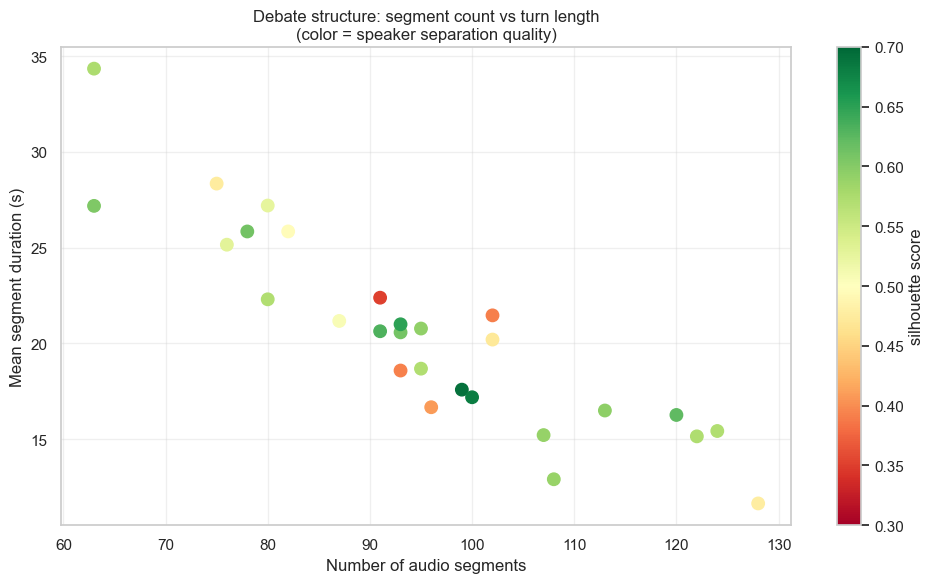

In [49]:
# Debate structure: segment count vs mean turn length (colored by silhouette quality)
debate_stats = [{'video':v, 'n_segments':len(data[data['video']==v]),
                  'mean_duration':data[data['video']==v]['duration'].mean(),
                  'sil_score':quality_scores.get(v,np.nan)} for v in debate_videos]
stats_df = pd.DataFrame(debate_stats)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(stats_df['n_segments'], stats_df['mean_duration'],
                c=stats_df['sil_score'], cmap='RdYlGn', vmin=0.3, vmax=0.7, s=80)
plt.colorbar(sc, ax=ax, label='silhouette score')
ax.set_xlabel('Number of audio segments'); ax.set_ylabel('Mean segment duration (s)')
ax.set_title('Debate structure: segment count vs turn length\n(color = speaker separation quality)')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

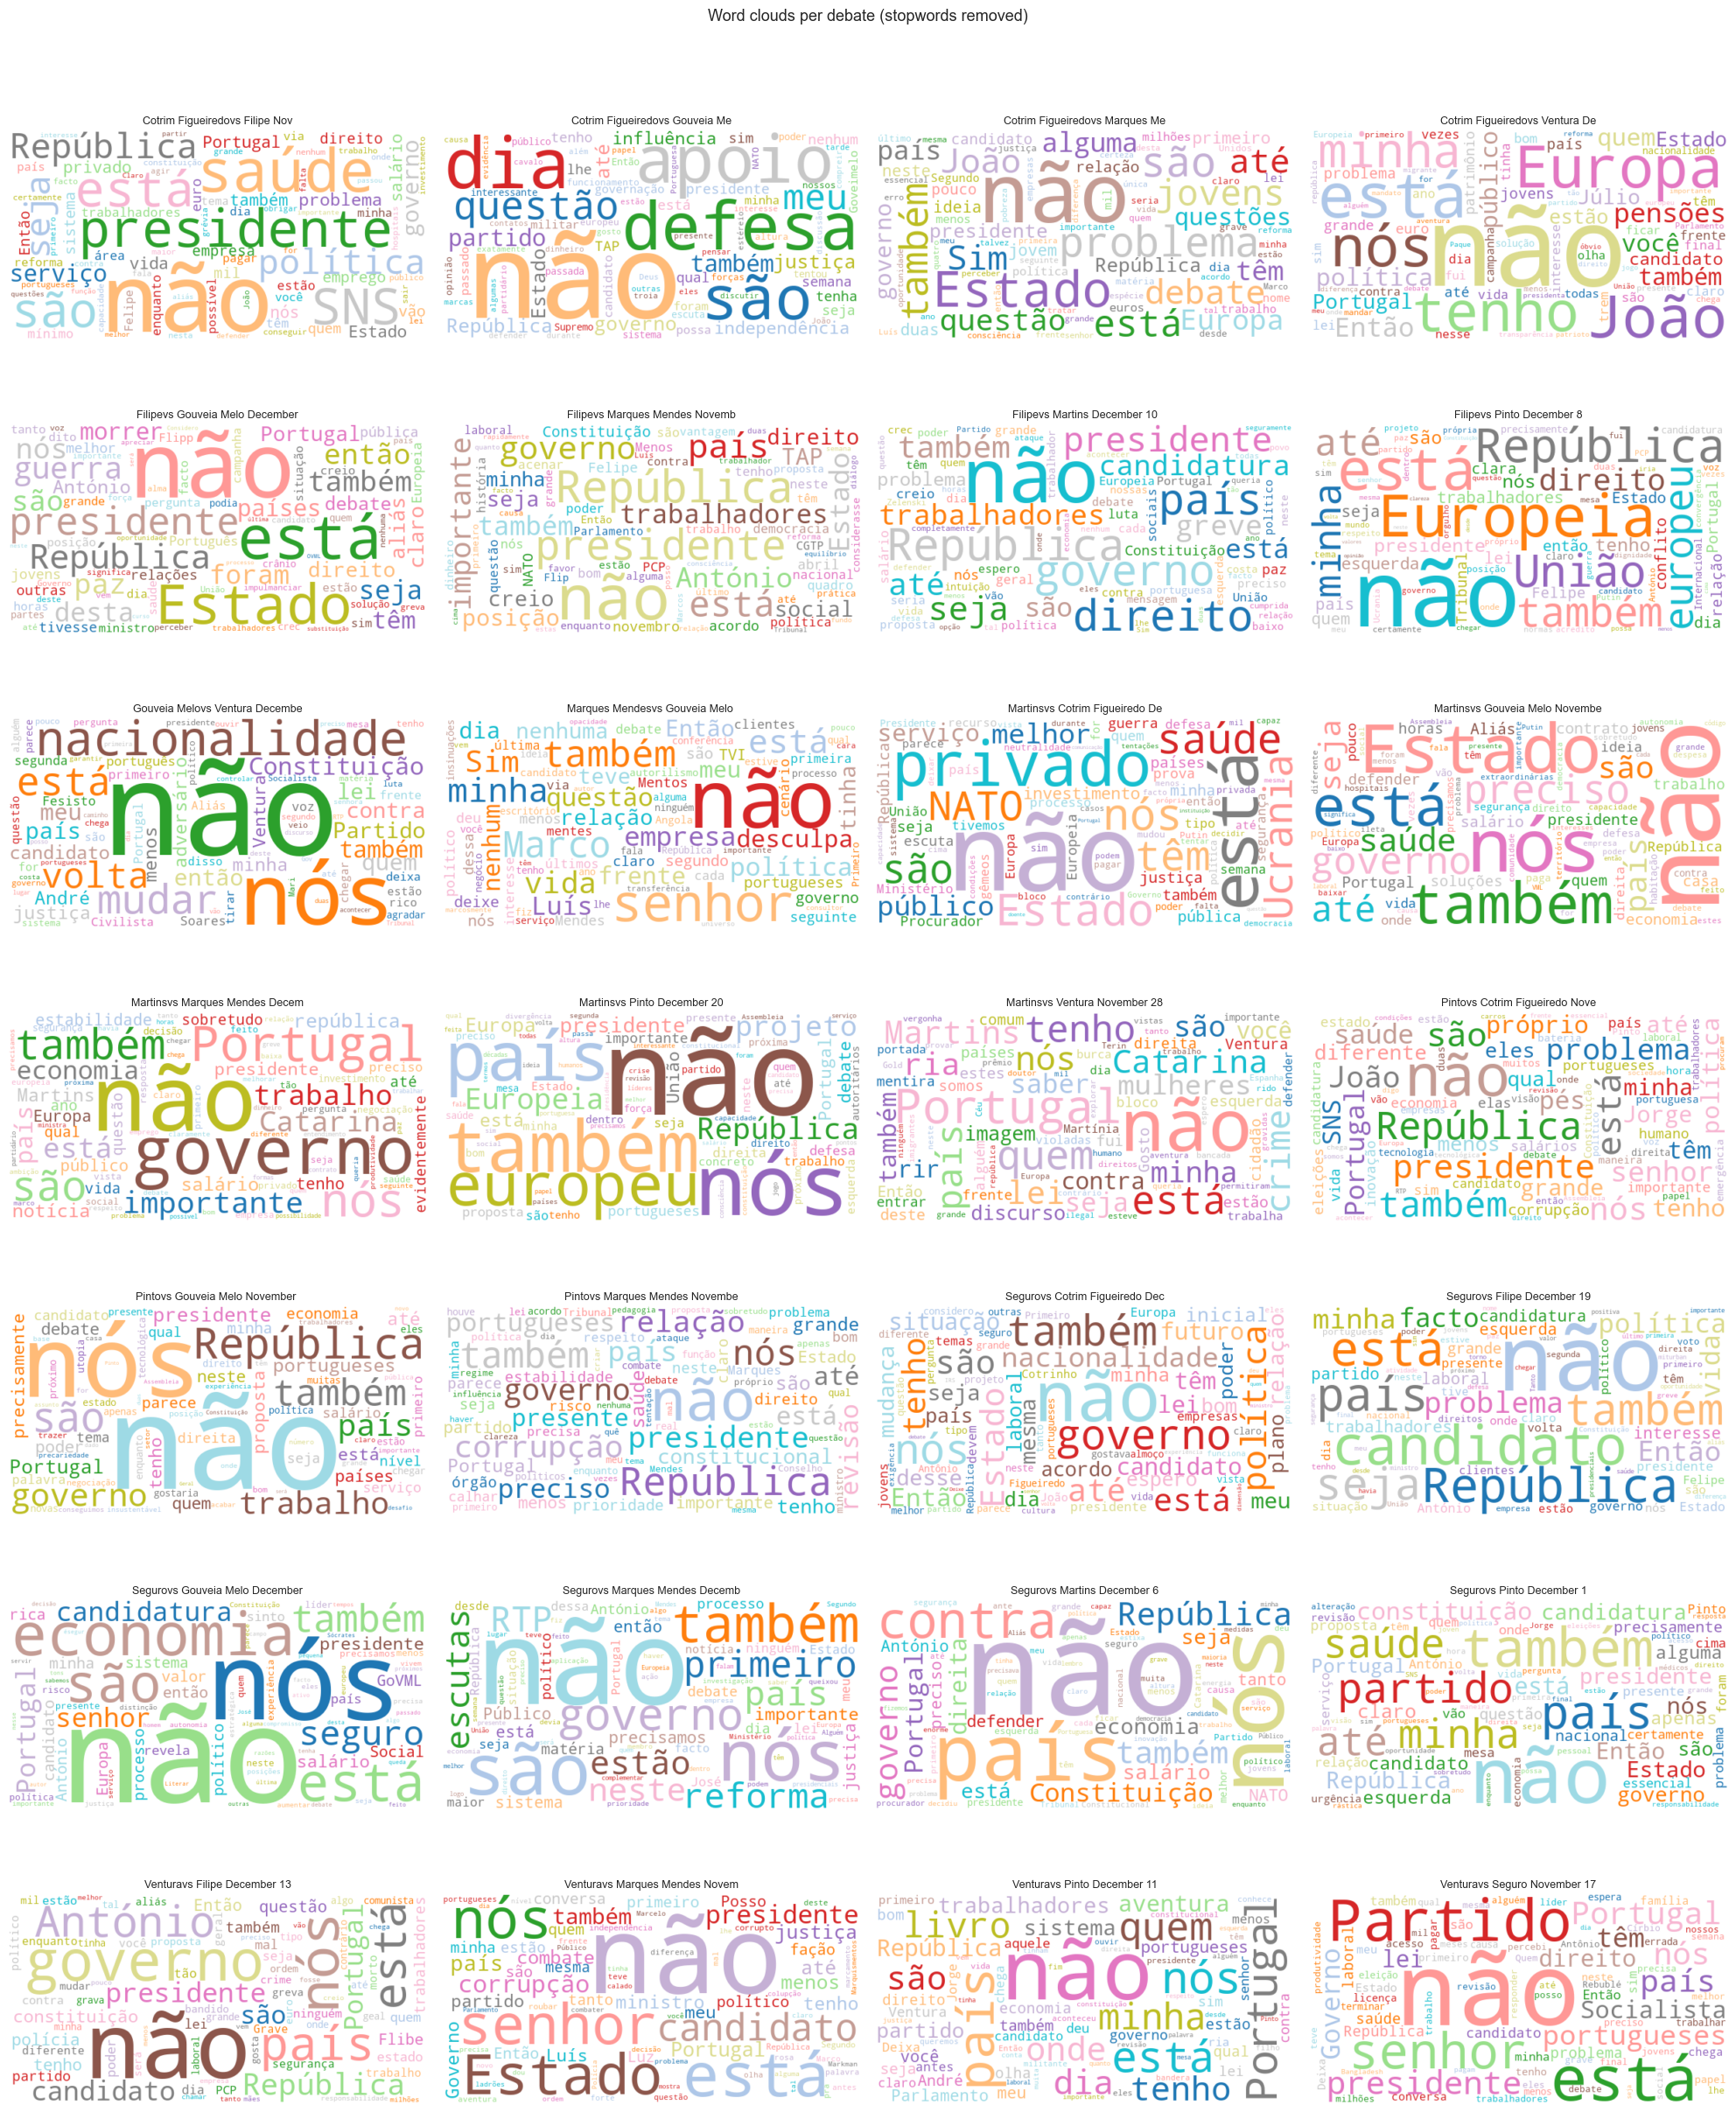

In [50]:
# Word clouds per debate
PT_STOPWORDS = {
    'de','a','o','que','e','do','da','em','um','para','uma','com','nao','por','mais',
    'as','dos','como','mas','foi','ao','ele','das','tem','seu','sua','ou','ser','quando',
    'muito','nos','ja','eu','tambem','so','pelo','pela','ate','isso','ela','entre','era',
    'depois','sem','mesmo','aos','seus','suas','numa','nem','nas','esse','essa','num','ha',
    'sobre','este','esta','foi','pelos','pelas','esses','essas','todo','toda','tudo','isto',
    'aqui','vos','lhes','dele','delas','nela','na','no','ter','sao','boa','noite','entao',
    'assim','porque','temos','agora','bem','vai','pode','vou','acho','anos','dizer','fazer',
    'coisa','coisas','aquilo','portanto','nada','nunca','sempre','ainda','hoje','estou',
    'estamos','estava','vamos','vao','sou','sabe','sei','quer','quero','querem','podemos',
    'deve','falar','faz','fez','disse','diz','ver','dar','estar','sendo','tendo','sido',
    'pessoa','pessoas','gente','lado','parte','forma','vez','caso','ponto','sentido','tempo',
    'momento','exemplo','questao','verdade','nosso','nossa','todos','outro','outros','outra',
    'alguem','ninguem','qualquer','mim','dois',
}

def make_wordcloud(text, title, ax):
    wc = WordCloud(width=600, height=300, background_color='white',
                   stopwords=PT_STOPWORDS, max_words=80, colormap='tab20',
                   min_word_length=3, collocations=False).generate(text)
    ax.imshow(wc, interpolation='bilinear'); ax.set_title(title, fontsize=9); ax.axis('off')

n = len(debate_videos); ncols = 4; nrows = math.ceil(n/ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows*3.5)); axes = axes.flatten()
for i, v in enumerate(sorted(debate_videos)):
    txt = ' '.join(speech_debates[speech_debates['video']==v]['transcript'].dropna().astype(str))
    make_wordcloud(txt, v.replace('_',' ').replace(' vs ','vs ')[:30], axes[i])
for j in range(i+1, len(axes)): axes[j].axis('off')
plt.suptitle('Word clouds per debate (stopwords removed)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

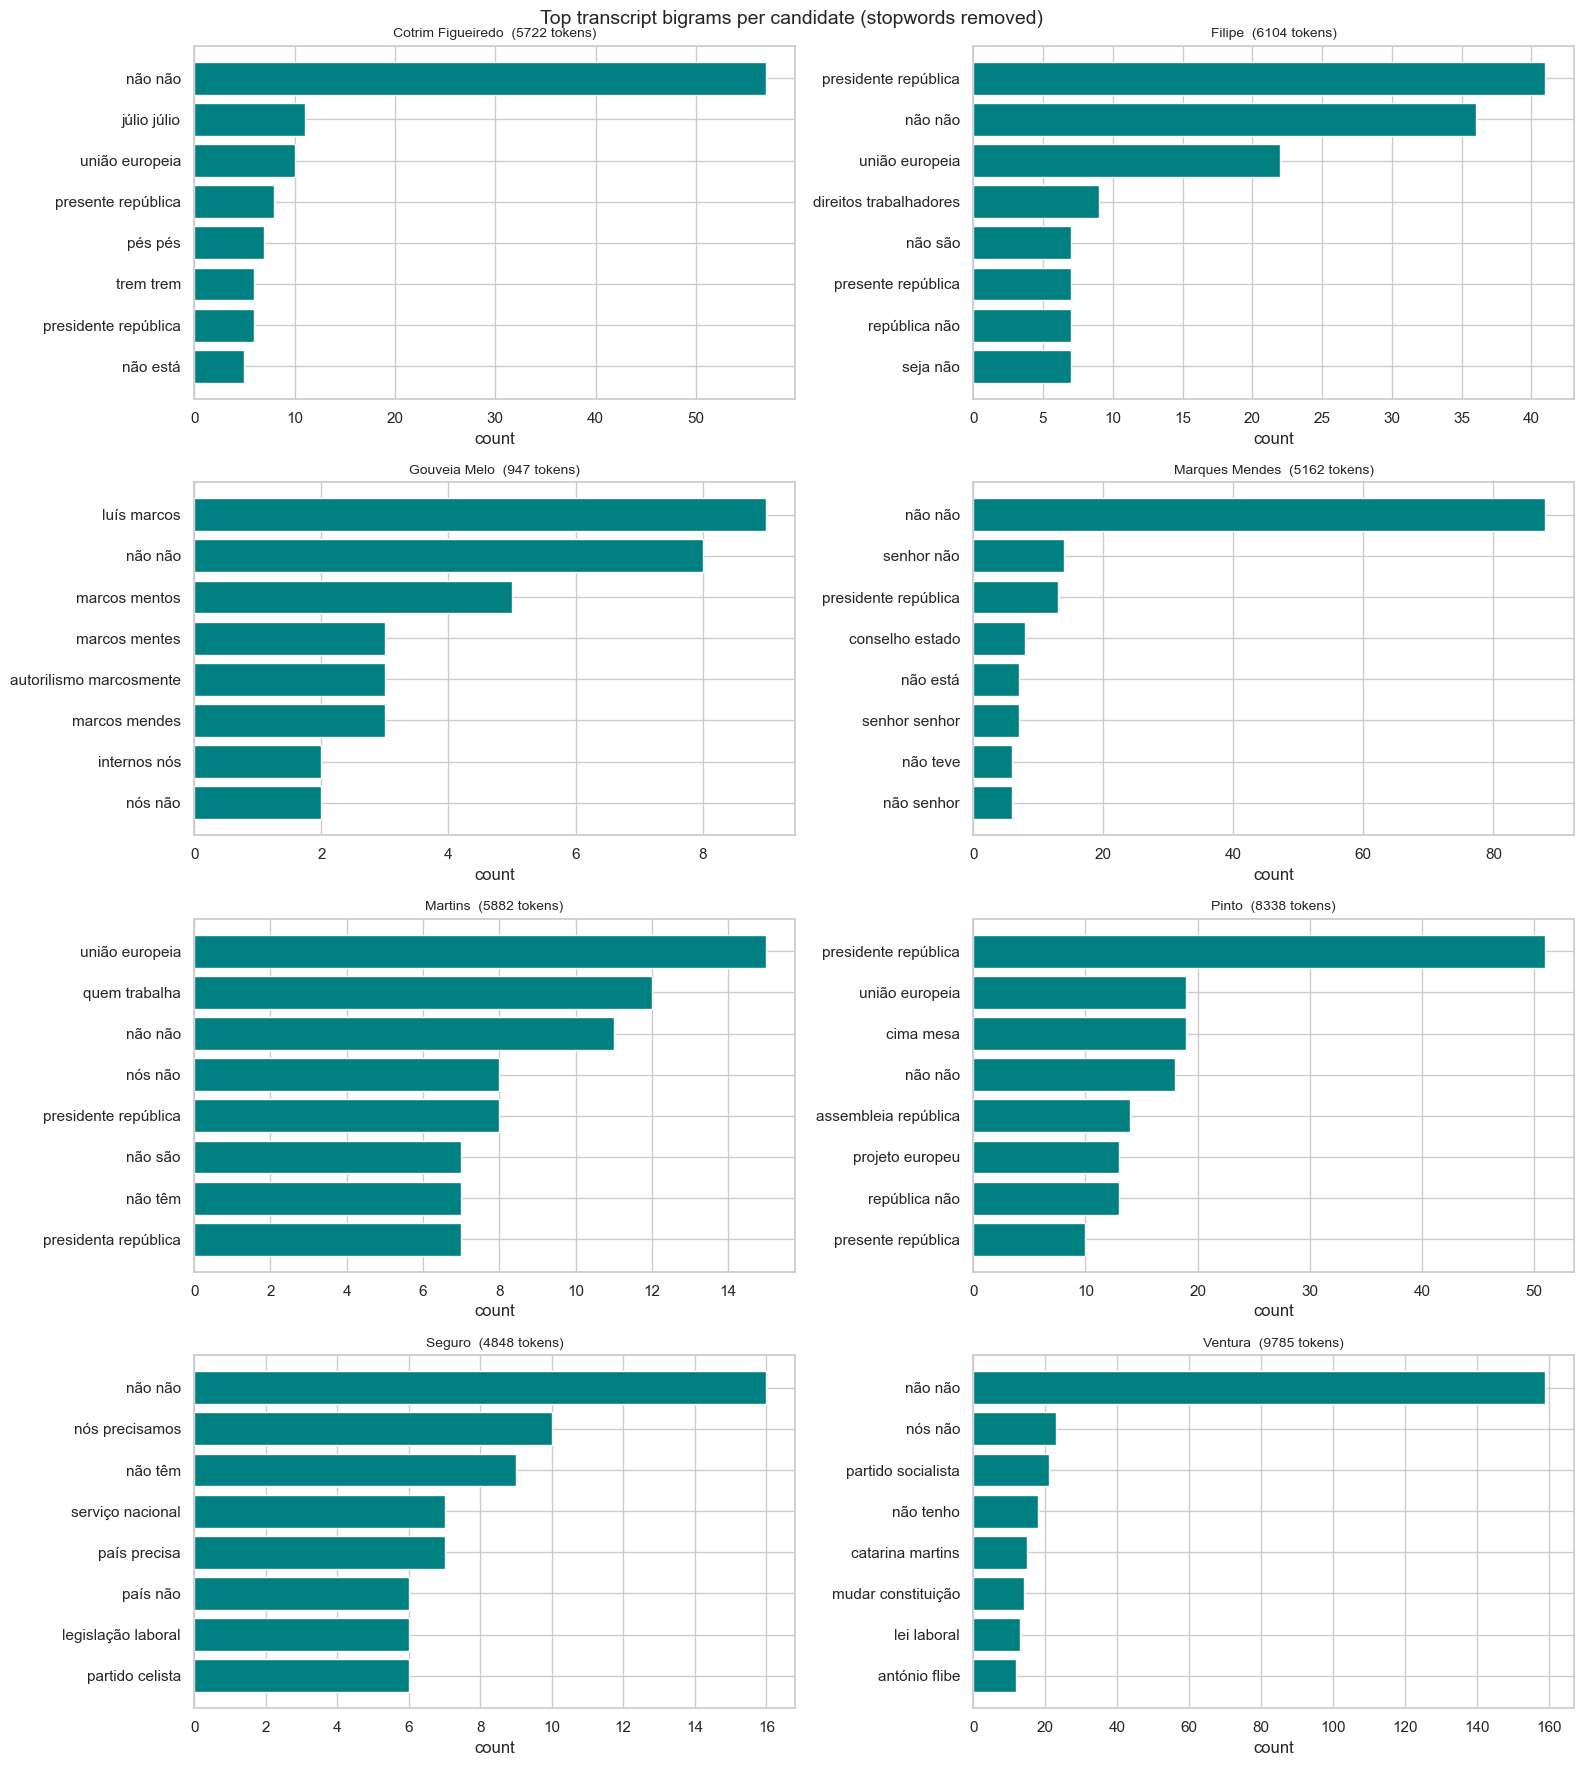

In [51]:
# Per-candidate bigrams
def tokenize(text, sw=PT_STOPWORDS, ml=3):
    tokens = re.findall(r'[a-zà-ÿ]+(?:-[a-zà-ÿ]+)?',
                        str(text).lower(), flags=re.IGNORECASE)
    return [t for t in tokens if len(t)>=ml and t not in sw]

candidate_text = speech_labeled[
    speech_labeled['video'].isin(debate_videos) &
    speech_labeled['speaker'].isin(CANDIDATES)
].copy()
candidate_text['tokens'] = candidate_text['transcript'].apply(tokenize)

fig, axes = plt.subplots(4, 2, figsize=(16, 18)); axes = axes.flatten()
for ax, cand in zip(axes, sorted(CANDIDATES)):
    sub = candidate_text[candidate_text['speaker']==cand]
    all_tokens = [t for toks in sub['tokens'] for t in toks]
    bigrams = Counter(zip(all_tokens, all_tokens[1:])).most_common(8)
    if not bigrams: ax.axis('off'); continue
    labels  = [' '.join(bg) for bg,_ in bigrams]
    counts  = [c for _,c in bigrams]
    ax.barh(labels[::-1], counts[::-1], color='teal', edgecolor='white')
    ax.set_title(f'{cand.replace("_"," ")}  ({len(all_tokens)} tokens)', fontsize=10)
    ax.set_xlabel('count')
for ax in axes[len(CANDIDATES):]: ax.axis('off')
plt.suptitle('Top transcript bigrams per candidate (stopwords removed)', fontsize=14)
plt.tight_layout(); plt.show()

,candidate,tokens,unique,root_ttr,hapax_ratio,mean_words_per_seg
0,Cotrim_Figueiredo,5722,2726,36.0373,0.3300,140.2065
7,Ventura,9785,3335,33.7144,0.2126,244.1474
1,Filipe,6104,2626,33.6115,0.2908,142.1633
5,Pinto,8338,2976,32.5913,0.2238,173.4352
4,Martins,5882,2306,30.0675,0.2429,132.4455
6,Seguro,4848,2050,29.4424,0.2735,113.6170
3,Marques_Mendes,5162,2091,29.1035,0.2575,103.6000
2,Gouveia_Melo,947,590,19.1724,0.4731,83.3600


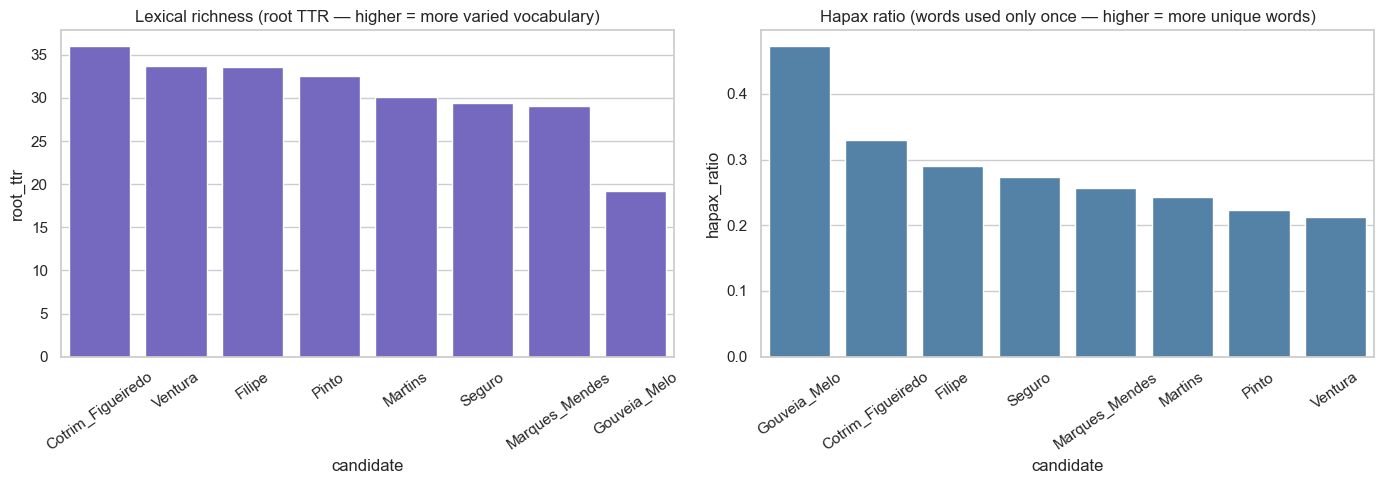

In [52]:
# Lexical richness per candidate
lex_rows = []
for cand, sub in candidate_text.groupby('speaker'):
    tokens = [t for toks in sub['tokens'] for t in toks]
    counts = Counter(tokens)
    n = len(tokens); u = len(counts); h = sum(1 for c in counts.values() if c==1)
    lex_rows.append({'candidate':cand,'tokens':n,'unique':u,
                     'root_ttr': u/max(n,1)**0.5,'hapax_ratio':h/max(n,1),
                     'mean_words_per_seg': sub['word_count'].mean()})
lex = pd.DataFrame(lex_rows).sort_values('root_ttr', ascending=False)
display(lex.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=lex, x='candidate', y='root_ttr',
            order=lex.sort_values('root_ttr',ascending=False)['candidate'],
            color='slateblue', ax=axes[0])
axes[0].set_title('Lexical richness (root TTR — higher = more varied vocabulary)')
axes[0].tick_params(axis='x', rotation=35)
sns.barplot(data=lex, x='candidate', y='hapax_ratio',
            order=lex.sort_values('hapax_ratio',ascending=False)['candidate'],
            color='steelblue', ax=axes[1])
axes[1].set_title('Hapax ratio (words used only once — higher = more unique words)')
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()

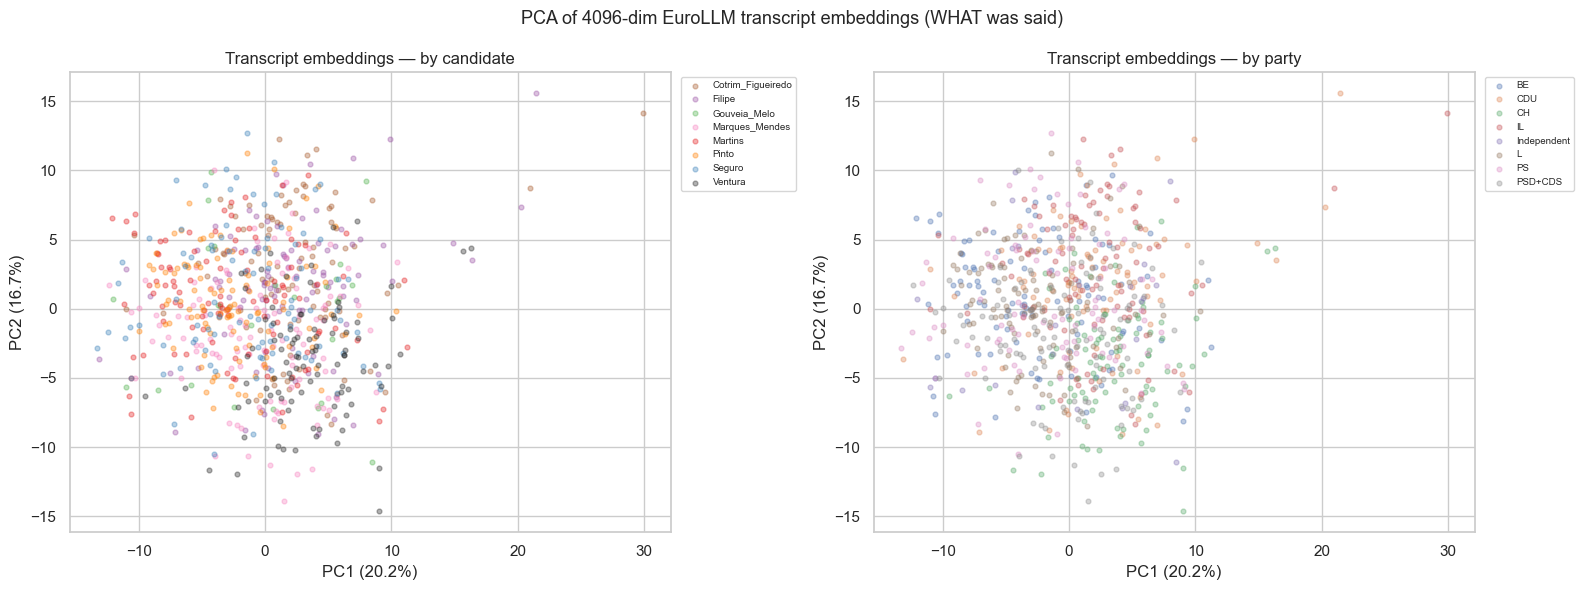

In [53]:
# Transcript embedding PCA — do candidates cluster by WHAT they say?
emb_col = 'text_embedding'
speech_cands = candidate_text.dropna(subset=[emb_col]).copy()
speech_cands[emb_col] = speech_cands[emb_col].apply(
    lambda x: x if isinstance(x, np.ndarray) else np.fromstring(str(x).strip('[]'), sep=' '))

T = np.stack(speech_cands[emb_col].values)
pca_t = PCA(n_components=2, random_state=42)
T_2d  = pca_t.fit_transform(PCA(50, random_state=42).fit_transform(T))
v1, v2 = pca_t.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for cand in CANDIDATES:
    mask = speech_cands['speaker'].values == cand
    axes[0].scatter(T_2d[mask,0], T_2d[mask,1], label=cand, alpha=0.35, s=12,
                    color=color_map.get(cand,'grey'))
axes[0].set_title('Transcript embeddings — by candidate')
axes[0].set_xlabel(f'PC1 ({v1:.1f}%)'); axes[0].set_ylabel(f'PC2 ({v2:.1f}%)')
axes[0].legend(fontsize=7, bbox_to_anchor=(1.01,1), loc='upper left')

parties = speech_cands['party'].fillna('host').values
for p in sorted(set(parties)):
    mask = parties==p
    axes[1].scatter(T_2d[mask,0], T_2d[mask,1], label=p, alpha=0.35, s=12)
axes[1].set_title('Transcript embeddings — by party')
axes[1].set_xlabel(f'PC1 ({v1:.1f}%)'); axes[1].set_ylabel(f'PC2 ({v2:.1f}%)')
axes[1].legend(fontsize=7, bbox_to_anchor=(1.01,1), loc='upper left')

plt.suptitle('PCA of 4096-dim EuroLLM transcript embeddings (WHAT was said)', fontsize=13)
plt.tight_layout(); plt.show()

,candidate,debates,mean_sim
5,Pinto,7,0.996
6,Seguro,7,0.996
7,Ventura,7,0.995
0,Cotrim_Figueiredo,7,0.995
1,Filipe,7,0.995
3,Marques_Mendes,7,0.995
4,Martins,7,0.994
2,Gouveia_Melo,2,0.977


/var/folders/5g/t8kckpys61zdtmy3jx9lt0z00000gn/T/ipykernel_4972/363702282.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df.dropna(), x='candidate', y='mean_sim',


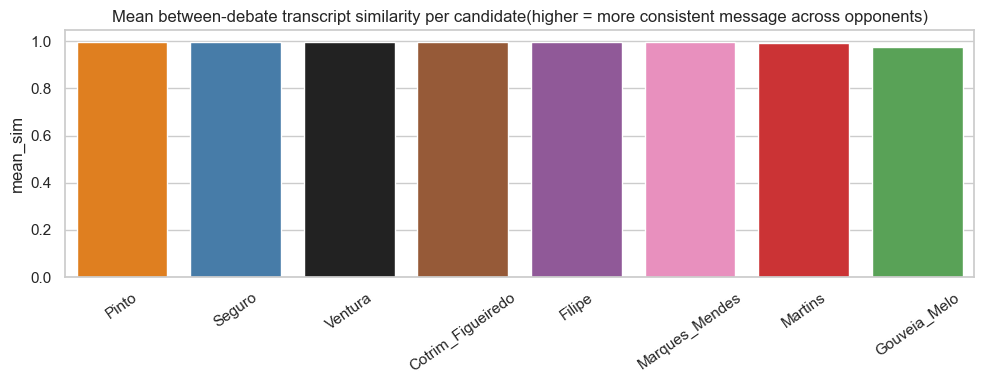

In [54]:
# Per-candidate between-debate transcript similarity
# High cosine similarity = candidate keeps same semantic content across different opponents
from scipy.spatial.distance import cdist as _cdist
MIN_SEGS = 5; MONTH_MAP = {'November':11,'December':12,'January':1}

def parse_debate_date_sort(v):
    m = re.search(r'(January|November|December)_(\d+)', v)
    if not m: return (99,99)
    return (MONTH_MAP.get(m.group(1),99), int(m.group(2)))

summary_rows = []
for cand in CANDIDATES:
    sub = speech_cands[speech_cands['speaker']==cand]
    debate_centroids_t = []
    for v, dg in sub.groupby('video'):
        if len(dg) < MIN_SEGS: continue
        c = np.stack(dg[emb_col].values).mean(axis=0)
        debate_centroids_t.append({'video':v,'centroid':c,'n':len(dg)})
    if len(debate_centroids_t) < 2:
        summary_rows.append({'candidate':cand,'debates':len(debate_centroids_t),'mean_sim':np.nan})
        continue
    cents = np.stack([r['centroid'] for r in debate_centroids_t])
    sim   = 1 - _cdist(cents, cents, metric='cosine')
    off   = sim[np.triu_indices_from(sim,k=1)]
    summary_rows.append({'candidate':cand,'debates':len(debate_centroids_t),'mean_sim':off.mean()})

summary_df = pd.DataFrame(summary_rows).sort_values('mean_sim', ascending=False)
display(summary_df.round(3))

fig, ax = plt.subplots(figsize=(10,4))
sns.barplot(data=summary_df.dropna(), x='candidate', y='mean_sim',
            palette=[color_map.get(c,'grey') for c in summary_df.dropna()['candidate']], ax=ax)
ax.set_title('Mean between-debate transcript similarity per candidate''(higher = more consistent message across opponents)', fontsize=12)
ax.set_xlabel(''); ax.tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()

### I.D.1 — Transcript topic modeling: 4 approaches

These four analyses use the 4096-dim EuroLLM transcript embeddings to answer
different questions about candidate semantics. They extend the PCA visualisation
and between-debate similarity already shown above into four concrete,
statistically testable findings.

All four reuse `speech_cands` (candidate speech segments with parsed text
embeddings) defined in the cell above.

| Option | Question |
|--------|----------|
| **A** | What topics exist? KMeans on embeddings → per-candidate topic distribution histogram |
| **B** | Which candidates talk about similar things? Cosine similarity matrix + dendrogram |
| **C** | How consistent is each candidate's message? Discipline score + poll correlation |
| **D** | Does a candidate's agenda drift over the campaign? Semantic trajectory with arrows |

---
## Option A — Topic distribution per candidate

**Approach:** cluster all candidate speech segments in text-embedding space into K topics,
label each cluster with its top TF-IDF terms, then build a per-candidate topic histogram.

Comparing candidates in topic-distribution space is statistically sound (chi-square test)
and immediately interpretable — unlike comparing raw embedding centroids.

Variance explained by 50 PCs: 76.2%


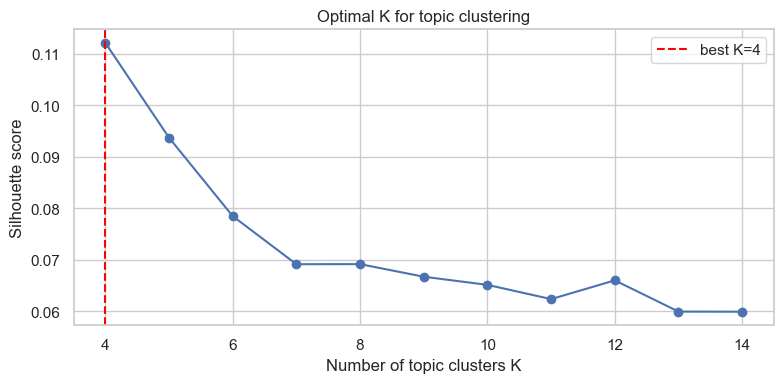

Best K: 4


In [55]:
# Reduce 4096-d text embeddings to 50 PCs before clustering
# (speeds up KMeans dramatically; PCA preserves most semantic variance)
X = np.stack(speech_cands['text_embedding'].values)
pca_pre = PCA(n_components=50, random_state=42)
X50 = pca_pre.fit_transform(X)
print(f'Variance explained by 50 PCs: {pca_pre.explained_variance_ratio_.sum():.1%}')

# Find optimal K via silhouette score (K = 4 … 14)
sil = []
K_range = range(4, 15)
for k in K_range:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X50)
    sil.append(silhouette_score(X50, labels, sample_size=min(500, len(X50))))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), sil, marker='o')
ax.set_xlabel('Number of topic clusters K')
ax.set_ylabel('Silhouette score')
ax.set_title('Optimal K for topic clustering')
best_K = list(K_range)[int(np.argmax(sil))]
ax.axvline(best_K, color='red', ls='--', label=f'best K={best_K}')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Best K: {best_K}')

In [56]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Fit final KMeans with best_K
km_topics = KMeans(n_clusters=best_K, random_state=42, n_init=20)
speech_cands = speech_cands.copy()
speech_cands['topic'] = km_topics.fit_predict(X50)

# Label each cluster with top TF-IDF terms from the transcripts it contains
PT_STOP = {
    'de','a','o','que','e','do','da','em','um','para','com','uma','os','no','se',
    'na','por','mais','as','dos','como','mas','ao','ele','das','tem','seu','sua',
    'ou','ser','quando','muito','nos','ja','eu','so','pelo','pela','ate','isso',
    'ela','entre','era','depois','sem','mesmo','aos','ter','seus','suas','numa',
    'nem','nas','esse','nao','num','ha','sobre','este','foi','pelos','pelas',
    'essa','esses','essas','isto','aqui','la','cada','qual','todo','toda','todos',
    'todas','outro','outra','outros','outras','ainda','pois','porque','assim',
    'lhe','temos','pode','podem','vai','sao','esta','tenho','diz','bem','pouco',
    'onde','menos','desde','antes','depois','contra','diante','conforme','segundo',
    'exceto','salvo','aquele','aquela','neste','nessa','naquele','vamos','vemos',
    'disse','disser','tambem','aquilo','ali','tudo','nada','sempre','nunca',
    'agora','entao','porem','contudo','todavia','portanto','logo','pois',
    'nem','quer','seja','caso','apos','durante','perante','mediante','junto'
}

def clean(t):
    t = str(t).lower()
    t = re.sub(r'[^\w\s]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

speech_cands['clean_text'] = speech_cands['transcript'].apply(clean)

tfidf = TfidfVectorizer(max_features=8000, min_df=2, stop_words=list(PT_STOP))
X_tfidf = tfidf.fit_transform(speech_cands['clean_text'])
terms = np.array(tfidf.get_feature_names_out())

topic_labels = {}
for k in range(best_K):
    mask = speech_cands['topic'] == k
    if mask.sum() == 0:
        topic_labels[k] = f'T{k}'
        continue
    mean_tfidf = np.asarray(X_tfidf[mask].mean(axis=0)).flatten()
    top5 = terms[mean_tfidf.argsort()[-5:][::-1]]
    topic_labels[k] = f'T{k}: ' + ', '.join(top5)
    print(f'Topic {k:2d} ({mask.sum():3d} segs): {topic_labels[k]}')

speech_cands['topic_label'] = speech_cands['topic'].map(topic_labels)

AttributeError: 'Series' object has no attribute 'nonzero'

In [ ]:
# Per-candidate topic distribution — stacked bar chart
pivot = (speech_cands.groupby(['speaker', 'topic_label'])
         .size().unstack(fill_value=0))
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.loc[CANDIDATES]  # consistent row order

fig, ax = plt.subplots(figsize=(13, 6))
pivot_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.7)
ax.set_xlabel('')
ax.set_ylabel('% of speech segments')
ax.set_title('Topic distribution per candidate (stacked, % of their speech)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_xticklabels([c.replace('_', ' ') for c in pivot_pct.index], rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import chi2_contingency
# Chi-square test of independence: are topic distributions different across candidates?
contingency = (speech_cands[speech_cands['speaker'].isin(CANDIDATES)]
               .groupby(['speaker', 'topic']).size().unstack(fill_value=0))
contingency = contingency.loc[CANDIDATES]

chi2, p, dof, expected = chi2_contingency(contingency.values)
print(f'Chi-square test (candidate × topic)')
print(f'  chi2 = {chi2:.1f},  dof = {dof},  p = {p:.2e}')
if p < 0.05:
    print('  -> Topic distributions differ significantly across candidates (p < 0.05)')
else:
    print('  -> No significant difference in topic distributions (p >= 0.05)')

# Which candidate dominates each topic?
print()
print('Dominant candidate per topic:')
for t in range(best_K):
    col = contingency[t] if t in contingency.columns else pd.Series(dtype=float)
    if col.sum() > 0:
        dom = col.idxmax()
        share = 100 * col[dom] / col.sum()
        print(f'  T{t:2d}: {dom} ({share:.0f}% of segs in this topic)')

---
## Option B — Pairwise cosine similarity between candidates

Compute each candidate's centroid in the original 4096-d text-embedding space,
then measure cosine similarity between all pairs.
This is the correct metric for embeddings (unlike Pearson correlation, which
measures linear co-variation across dimensions that have no individual meaning).

**If the text embeddings capture political content, the similarity matrix should
recover the left ↔ right spectrum without any supervision.**

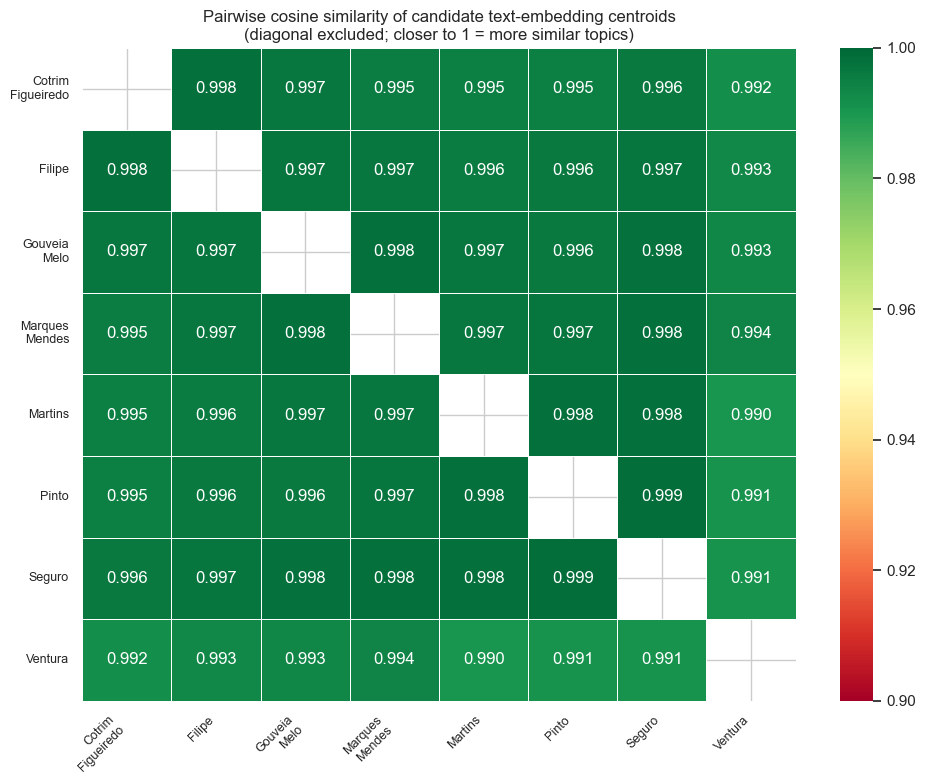

In [ ]:
# Candidate centroids in original 4096-d space (NOT PCA-reduced)
centroids_text = {}
for c in CANDIDATES:
    segs = speech_cands[speech_cands['speaker'] == c]['text_embedding']
    if len(segs) > 0:
        centroids_text[c] = np.mean(np.stack(segs.values), axis=0)

cands_present = [c for c in CANDIDATES if c in centroids_text]

# Cosine similarity matrix
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)

n = len(cands_present)
sim_matrix = np.zeros((n, n))
for i, ci in enumerate(cands_present):
    for j, cj in enumerate(cands_present):
        sim_matrix[i, j] = cosine_sim(centroids_text[ci], centroids_text[cj])

sim_df = pd.DataFrame(sim_matrix, index=cands_present, columns=cands_present)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask_diag = np.eye(n, dtype=bool)
sns.heatmap(sim_df, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.9, vmax=1.0,
            ax=ax, mask=mask_diag, linewidths=0.5)
ax.set_title('Pairwise cosine similarity of candidate text-embedding centroids\n'
             '(diagonal excluded; closer to 1 = more similar topics)')
short = {c: c.replace('_', '\n') for c in cands_present}
ax.set_xticklabels([short[c] for c in cands_present], rotation=45, ha='right', fontsize=9)
ax.set_yticklabels([short[c] for c in cands_present], rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

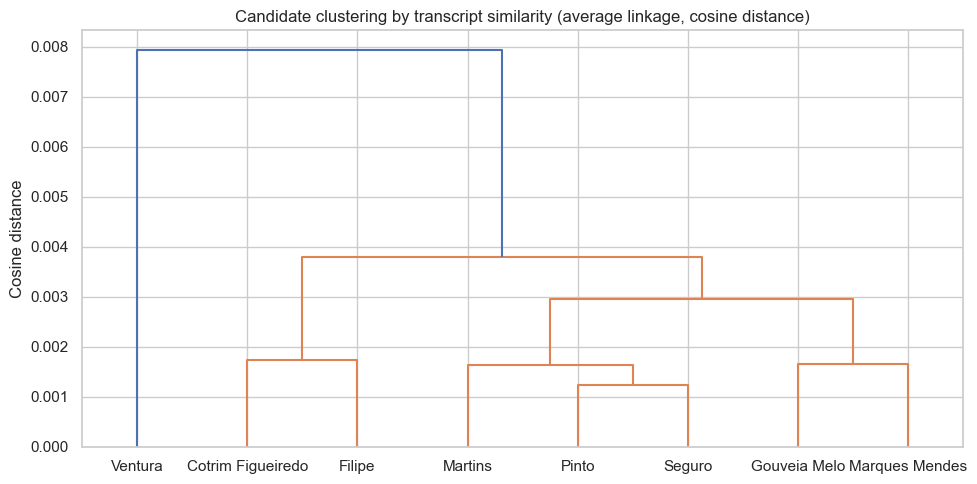

Most similar pairs:
  Pinto — Seguro: 0.9988
  Martins — Seguro: 0.9984
  Martins — Pinto: 0.9984
Least similar pairs:
  Seguro — Ventura: 0.9908
  Pinto — Ventura: 0.9907
  Martins — Ventura: 0.9903


In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
# Hierarchical clustering dendrogram — which candidates are semantically closest?
dist_matrix = 1.0 - sim_matrix  # cosine distance
np.fill_diagonal(dist_matrix, 0)
# Convert to condensed form for scipy linkage
from scipy.spatial.distance import squareform
Z = linkage(squareform(dist_matrix), method='average')

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(Z, labels=[c.replace('_', ' ') for c in cands_present],
           ax=ax, color_threshold=0.6*max(Z[:,2]),
           leaf_font_size=11)
ax.set_title('Candidate clustering by transcript similarity (average linkage, cosine distance)')
ax.set_ylabel('Cosine distance')
plt.tight_layout()
plt.show()

# Print most and least similar pairs (excluding diagonal)
pairs = []
for i in range(n):
    for j in range(i+1, n):
        pairs.append((cands_present[i], cands_present[j], sim_matrix[i,j]))
pairs.sort(key=lambda x: x[2], reverse=True)
print('Most similar pairs:')
for a,b,s in pairs[:3]: print(f'  {a} — {b}: {s:.4f}')
print('Least similar pairs:')
for a,b,s in pairs[-3:]: print(f'  {a} — {b}: {s:.4f}')

---
## Option C — Message discipline (intra-candidate semantic consistency)

**Idea:** a candidate with low within-candidate variance in text-embedding space
talks about the same things in every debate — high message discipline.
A candidate with high variance shifts topics debate to debate.

Metric: mean pairwise cosine similarity among all of a candidate's speech segments.
Higher = more consistent. We then correlate this with mean poll standing.

        candidate  n_segs  mean_cosine_sim  semantic_variance
          Ventura      95         0.962328           0.037672
            Pinto     108         0.960602           0.039398
   Marques_Mendes     110         0.954653           0.045347
           Seguro      94         0.953198           0.046802
          Martins     101         0.951135           0.048865
Cotrim_Figueiredo      92         0.951081           0.048919
     Gouveia_Melo      25         0.944996           0.055004
           Filipe      98         0.944526           0.055474


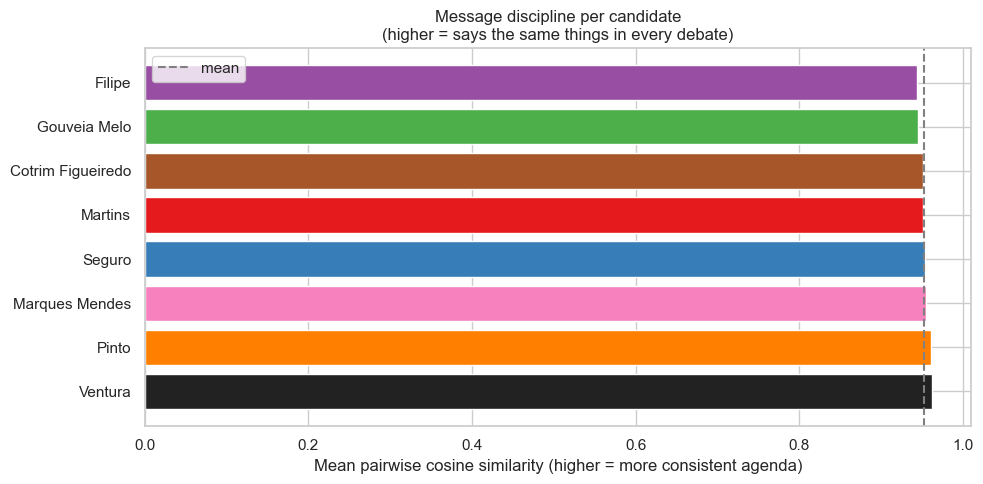

In [ ]:
disc_rows = []
for c in CANDIDATES:
    segs = np.stack(speech_cands[speech_cands['speaker'] == c]['text_embedding'].values)
    if len(segs) < 2:
        continue
    # Normalize to unit sphere
    segs_norm = segs / (np.linalg.norm(segs, axis=1, keepdims=True) + 1e-12)
    # Mean pairwise cosine similarity = (sum of all dot products - n) / (n*(n-1))
    gram = segs_norm @ segs_norm.T
    n = len(segs)
    mean_sim = (gram.sum() - n) / (n * (n - 1))
    disc_rows.append({'candidate': c, 'n_segs': n,
                      'mean_cosine_sim': mean_sim,
                      'semantic_variance': 1 - mean_sim})

disc = pd.DataFrame(disc_rows).sort_values('mean_cosine_sim', ascending=False)
print(disc.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = [CAND_COLOR.get(c, '#888') for c in disc['candidate']]
ax.barh(disc['candidate'].str.replace('_', ' '), disc['mean_cosine_sim'], color=colors)
ax.set_xlabel('Mean pairwise cosine similarity (higher = more consistent agenda)')
ax.set_title('Message discipline per candidate\n(higher = says the same things in every debate)')
ax.axvline(disc['mean_cosine_sim'].mean(), ls='--', color='grey', label='mean')
ax.legend()
plt.tight_layout()
plt.show()

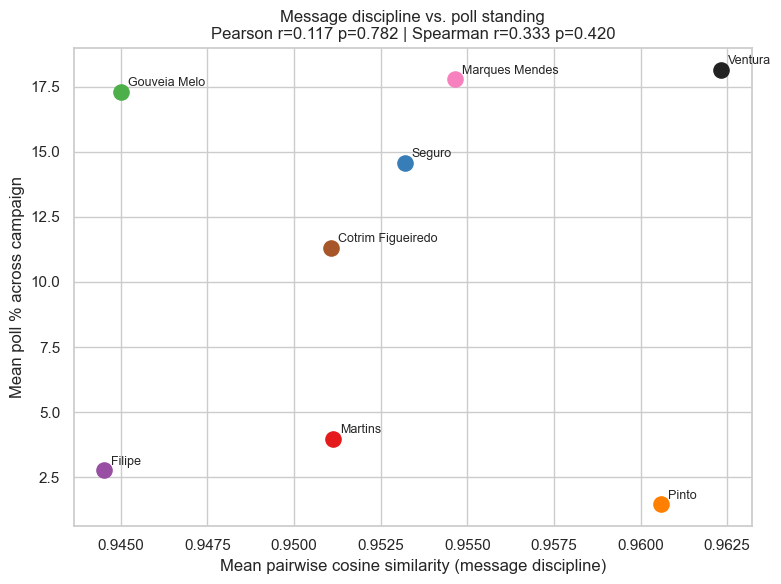

In [ ]:
# Correlate message discipline with poll standing
polls = pd.read_pickle(os.path.join(FEATURES_DIR, 'polls_timeline.pkl'))

# Mean poll % per candidate across all polls (proxy for overall campaign standing)
poll_mean = {c: polls[c].mean() for c in CANDIDATES if c in polls.columns}

disc['mean_poll_pct'] = disc['candidate'].map(poll_mean)
disc_valid = disc.dropna(subset=['mean_poll_pct'])

r_p, p_p = pearsonr(disc_valid['mean_cosine_sim'], disc_valid['mean_poll_pct'])
r_s, p_s = spearmanr(disc_valid['mean_cosine_sim'], disc_valid['mean_poll_pct'])

fig, ax = plt.subplots(figsize=(8, 6))
for _, row in disc_valid.iterrows():
    c = row['candidate']
    ax.scatter(row['mean_cosine_sim'], row['mean_poll_pct'],
               color=CAND_COLOR.get(c, '#888'), s=120, zorder=3)
    ax.annotate(c.replace('_', ' '), (row['mean_cosine_sim'], row['mean_poll_pct']),
                fontsize=9, xytext=(5, 4), textcoords='offset points')
ax.set_xlabel('Mean pairwise cosine similarity (message discipline)')
ax.set_ylabel('Mean poll % across campaign')
ax.set_title(f'Message discipline vs. poll standing\nPearson r={r_p:.3f} p={p_p:.3f} | '
             f'Spearman r={r_s:.3f} p={p_s:.3f}')
plt.tight_layout()
plt.show()

---
## Option D — Semantic drift: does a candidate's agenda shift over the campaign?

For each candidate, compute their mean text-embedding per debate (7 points each),
ordered by debate date. Reduce all 56 points (8 candidates × 7 debates) to 2D via PCA
and plot trajectories with arrows showing time direction.

A candidate whose trajectory is a tight cluster stayed on-message.
A candidate whose trajectory moves in a consistent direction shifted their agenda
as the election approached.

In [ ]:
from datetime import date
# Parse debate date from video filename
MONTHS = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
          'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}

def parse_date(video_name):
    m = re.search(r'(January|February|March|April|May|June|July|August|'
                  r'September|October|November|December)_(\d+)', video_name)
    if not m: return None
    mon = MONTHS[m.group(1)]
    day = int(m.group(2))
    yr = 2025 if mon >= 10 else 2026
    return date(yr, mon, day)

# Per-candidate × per-debate mean text embedding
drift_rows = []
for v in debate_videos:
    d = parse_date(v)
    if d is None: continue
    cA, cB = extract_candidates(v)
    for c in (cA, cB):
        if c is None: continue
        segs = speech_cands[(speech_cands['video'] == v) & (speech_cands['speaker'] == c)]
        if len(segs) == 0: continue
        centroid = np.mean(np.stack(segs['text_embedding'].values), axis=0)
        drift_rows.append({'candidate': c, 'video': v, 'date': d, 'centroid': centroid})

drift_df = pd.DataFrame(drift_rows).sort_values(['candidate', 'date']).reset_index(drop=True)
print(f'{len(drift_df)} candidate-debate centroids built')
print(drift_df.groupby('candidate').size())

56 candidate-debate centroids built
candidate
Cotrim_Figueiredo    7
Filipe               7
Gouveia_Melo         7
Marques_Mendes       7
Martins              7
Pinto                7
Seguro               7
Ventura              7
dtype: int64


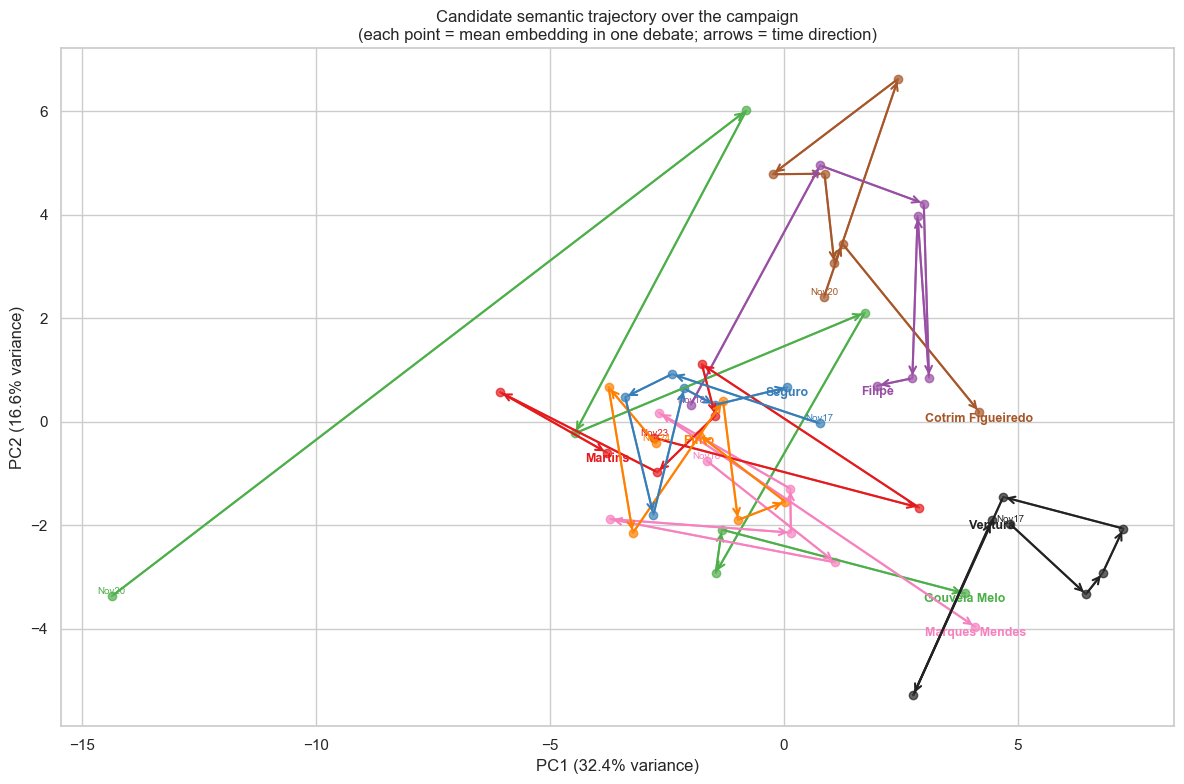

In [ ]:
# PCA to 2D on all per-candidate-per-debate centroids
C_matrix = np.stack(drift_df['centroid'].values)
pca2 = PCA(n_components=2, random_state=42)
C_2d = pca2.fit_transform(C_matrix)
drift_df['pc1'] = C_2d[:, 0]
drift_df['pc2'] = C_2d[:, 1]
var1, var2 = pca2.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(12, 8))
for c in CANDIDATES:
    sub = drift_df[drift_df['candidate'] == c].sort_values('date')
    if len(sub) < 2: continue
    color = CAND_COLOR.get(c, '#888')
    ax.plot(sub['pc1'], sub['pc2'], '-o', color=color, lw=1.5, alpha=0.7)
    # Arrows showing time direction
    for k in range(len(sub) - 1):
        ax.annotate('', xy=(sub['pc1'].iloc[k+1], sub['pc2'].iloc[k+1]),
                    xytext=(sub['pc1'].iloc[k], sub['pc2'].iloc[k]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
    # Label first and last point with date
    ax.text(sub['pc1'].iloc[0],  sub['pc2'].iloc[0],  sub['date'].iloc[0].strftime('%b%d'),
            fontsize=7, color=color, ha='center', va='bottom')
    ax.text(sub['pc1'].iloc[-1], sub['pc2'].iloc[-1], c.replace('_', ' '),
            fontsize=9, color=color, fontweight='bold', ha='center', va='top')

ax.set_xlabel(f'PC1 ({var1:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var2:.1f}% variance)')
ax.set_title('Candidate semantic trajectory over the campaign\n'
             '(each point = mean embedding in one debate; arrows = time direction)')
plt.tight_layout()
plt.show()

Semantic drift (sum of cosine distances between consecutive debates):
        candidate  total_drift  mean_step  n_debates
     Gouveia_Melo     0.134052   0.022342          7
          Martins     0.038968   0.006495          7
   Marques_Mendes     0.034916   0.005819          7
           Filipe     0.029045   0.004841          7
Cotrim_Figueiredo     0.028097   0.004683          7
          Ventura     0.026100   0.004350          7
            Pinto     0.021918   0.003653          7
           Seguro     0.021468   0.003578          7


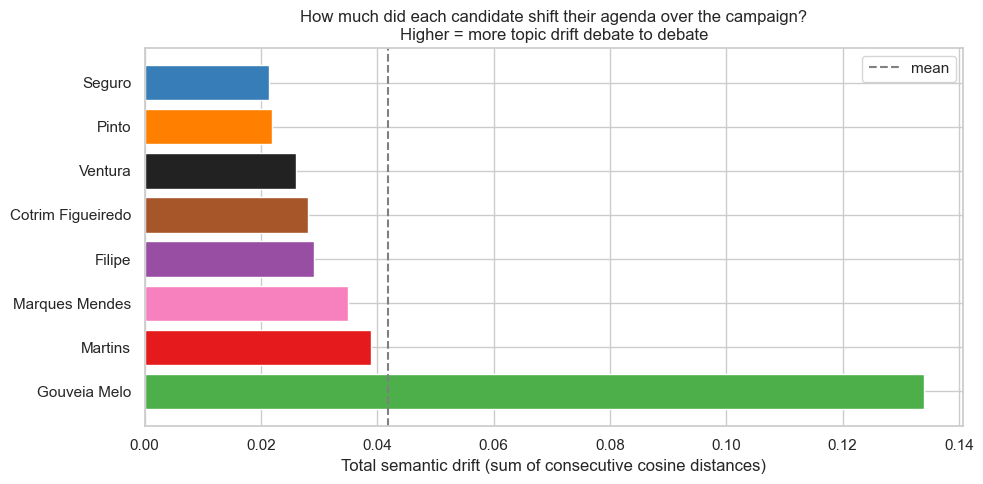

In [ ]:
# Quantify total semantic displacement per candidate:
# sum of step-by-step cosine distances between consecutive debates
displacement_rows = []
for c in CANDIDATES:
    sub = drift_df[drift_df['candidate'] == c].sort_values('date')
    if len(sub) < 2: continue
    vecs = np.stack(sub['centroid'].values)
    vecs_norm = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-12)
    step_dists = [1 - np.dot(vecs_norm[i], vecs_norm[i+1]) for i in range(len(vecs)-1)]
    displacement_rows.append({'candidate': c,
                               'total_drift': sum(step_dists),
                               'mean_step': np.mean(step_dists),
                               'n_debates': len(sub)})

disp = pd.DataFrame(displacement_rows).sort_values('total_drift', ascending=False)
print('Semantic drift (sum of cosine distances between consecutive debates):')
print(disp.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = [CAND_COLOR.get(c, '#888') for c in disp['candidate']]
ax.barh(disp['candidate'].str.replace('_', ' '), disp['total_drift'], color=colors)
ax.set_xlabel('Total semantic drift (sum of consecutive cosine distances)')
ax.set_title('How much did each candidate shift their agenda over the campaign?\n'
             'Higher = more topic drift debate to debate')
ax.axvline(disp['total_drift'].mean(), ls='--', color='grey', label='mean')
ax.legend()
plt.tight_layout()
plt.show()

## I.E — Within-debate dynamics: arousal trajectory + vocal entrainment

Averaged across all 28 debates:

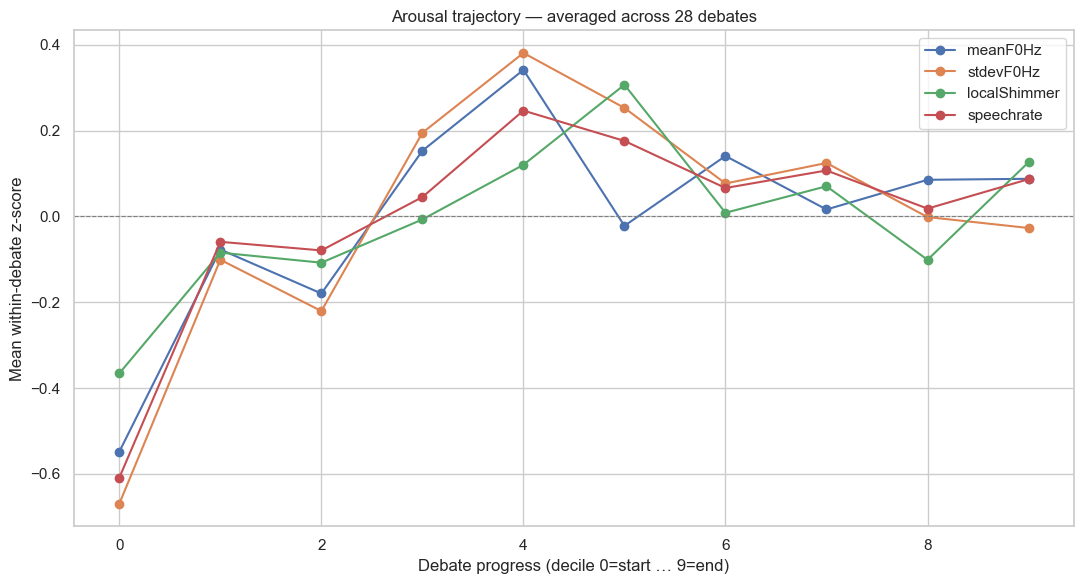

  meanF0Hz         r=+0.571  p=0.08  -> RISES
  stdevF0Hz        r=+0.482  p=0.16  -> RISES
  localShimmer     r=+0.553  p=0.10  -> RISES
  speechrate       r=+0.603  p=0.07  -> RISES


In [ ]:
# Arousal trajectory — does debate intensity rise toward the end?
from scipy.stats import pearsonr

AROUSAL_FEATS = ['meanF0Hz','stdevF0Hz','localShimmer','speechrate']
N_BINS = 10

traj_rows = []
for v in debate_videos:
    sub = data[(data['video']==v) & (data['speaker'].isin(CANDIDATES))].copy()
    if len(sub) < N_BINS: continue
    sub = sub.sort_values('time stamp')
    t = sub['time stamp'].values.astype(float)
    sub['progress'] = (t-t.min())/(t.max()-t.min()+1e-9)
    for f in AROUSAL_FEATS:
        x = sub[f].values.astype(float); sd = x.std()
        sub[f+'_z'] = (x-x.mean())/sd if sd>0 else 0.0
    sub['bin'] = np.minimum((sub['progress']*N_BINS).astype(int), N_BINS-1)
    for _,r in sub.iterrows():
        for f in AROUSAL_FEATS: traj_rows.append({'video':v,'bin':r['bin'],'feature':f,'z':r[f+'_z']})

traj = pd.DataFrame(traj_rows)
pivot = traj.groupby(['bin','feature'])['z'].mean().unstack()[AROUSAL_FEATS]

fig, ax = plt.subplots(figsize=(11, 6))
for f in AROUSAL_FEATS: ax.plot(pivot.index, pivot[f], marker='o', label=f)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel(f'Debate progress (decile 0=start … {N_BINS-1}=end)')
ax.set_ylabel('Mean within-debate z-score')
ax.set_title(f'Arousal trajectory — averaged across {traj["video"].nunique()} debates')
ax.legend(); plt.tight_layout(); plt.show()

for f in AROUSAL_FEATS:
    g = traj[traj['feature']==f].groupby('bin')['z'].mean()
    r,p = pearsonr(g.index.tolist(), g.values.tolist())
    print(f'  {f:16s} r={r:+.3f}  {"p<0.05" if p<0.05 else f"p={p:.2f}"}  -> {"RISES" if r>0 else "FALLS"}')

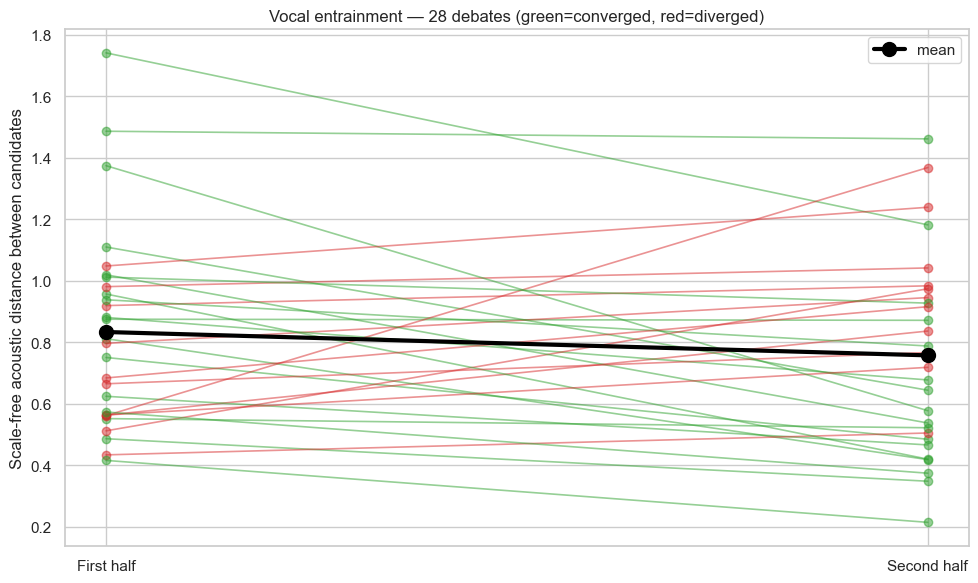

Debates: 28 | Converged: 17/28 (61%)
Mean dist  early=0.833  late=0.757
Wilcoxon  stat=147.0  p=0.210  -> CONVERGENCE


In [ ]:
# Vocal entrainment — do the two candidates' voices converge within a debate?
from scipy.stats import wilcoxon

ENTRAIN_FEATS = ['meanF0Hz','speechrate','articulationrate','stdevF0Hz']
ent_rows = []
for v in debate_videos:
    cA,cB = extract_candidates(v)
    if cA is None: continue
    sub = data[(data['video']==v) & (data['speaker'].isin([cA,cB]))].copy()
    if len(sub)<8: continue
    sub = sub.sort_values('time stamp')
    t = sub['time stamp'].values.astype(float)
    sub['progress'] = (t-t.min())/(t.max()-t.min()+1e-9)
    scale = sub[ENTRAIN_FEATS].std().values.astype(float); scale[scale==0]=1.0
    def half_means(hdf):
        out={}
        for c in (cA,cB):
            dc=hdf[hdf['speaker']==c]
            if len(dc)==0: return None
            out[c]=dc[ENTRAIN_FEATS].mean().values.astype(float)
        return out
    me=half_means(sub[sub['progress']<0.5]); ml=half_means(sub[sub['progress']>=0.5])
    if me is None or ml is None: continue
    ent_rows.append({'video':v,'dist_early':np.abs((me[cA]-me[cB])/scale).mean(),
                     'dist_late':np.abs((ml[cA]-ml[cB])/scale).mean()})

ent = pd.DataFrame(ent_rows); ent['converged']=ent['dist_late']<ent['dist_early']
fig, ax = plt.subplots(figsize=(10,6))
for _,r in ent.iterrows():
    ax.plot([0,1],[r['dist_early'],r['dist_late']],'-o',
            color='#2ca02c' if r['converged'] else '#d62728', alpha=0.5, lw=1.2)
ax.plot([0,1],[ent['dist_early'].mean(),ent['dist_late'].mean()],
        '-o',color='black',lw=3,markersize=10,label='mean')
ax.set_xticks([0,1]); ax.set_xticklabels(['First half','Second half'])
ax.set_ylabel('Scale-free acoustic distance between candidates')
ax.set_title(f'Vocal entrainment — {len(ent)} debates (green=converged, red=diverged)')
ax.legend(); plt.tight_layout(); plt.show()

n_conv=int(ent['converged'].sum()); n=len(ent)
print(f'Debates: {n} | Converged: {n_conv}/{n} ({100*n_conv/n:.0f}%)')
print(f'Mean dist  early={ent["dist_early"].mean():.3f}  late={ent["dist_late"].mean():.3f}')
if n>=6:
    stat,p=wilcoxon(ent['dist_early'].values,ent['dist_late'].values)
    print(f'Wilcoxon  stat={stat:.1f}  p={p:.3f}  -> {"CONVERGENCE" if ent["dist_late"].mean()<ent["dist_early"].mean() else "DIVERGENCE"}')

---
# Part II — Audio ↔ Visual correlations at multi-video scale

## II.1 Emotion ↔ Audio

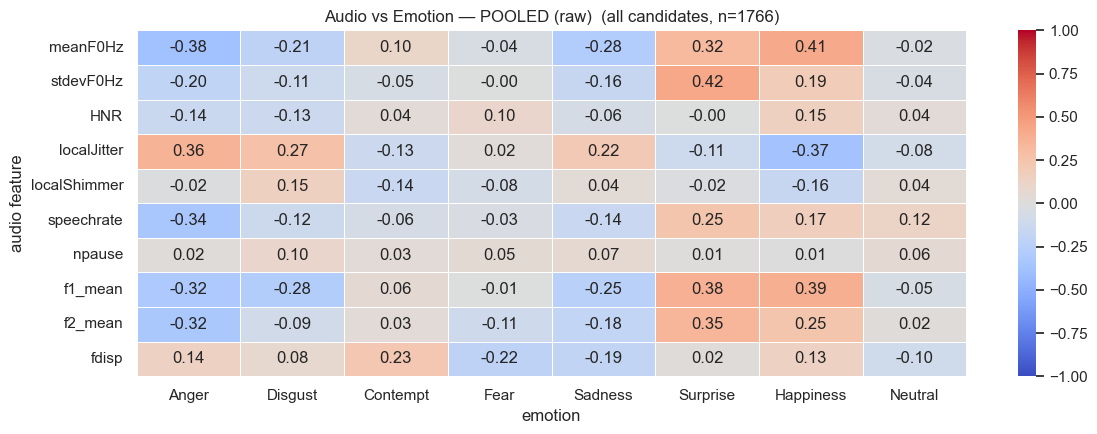

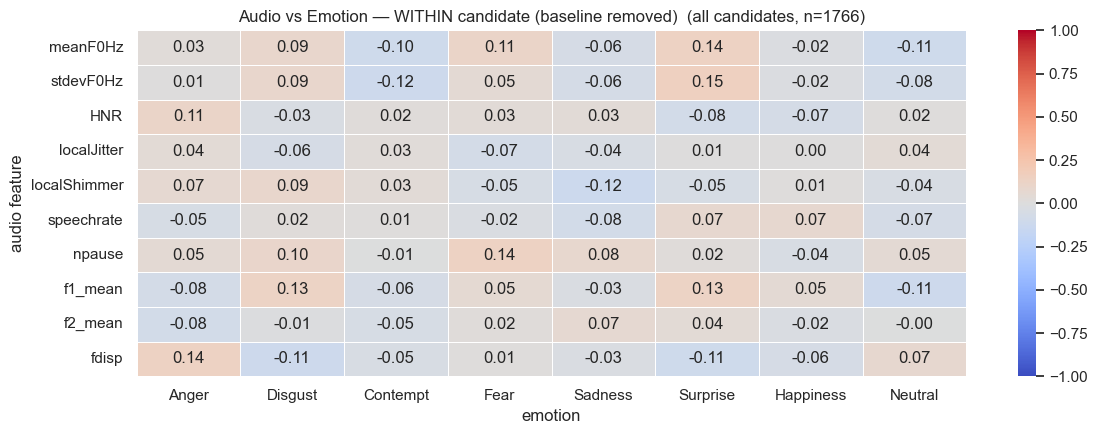

In [58]:
emotion_order = ['Anger','Disgust','Contempt','Fear','Sadness','Surprise','Happiness','Neutral']
ordered_prob  = [f'prob_{e}' for e in emotion_order]

pooled = seg_cands[NON_REDUNDANT + ordered_prob].corr('spearman').loc[NON_REDUNDANT, ordered_prob]

cen = seg_cands.copy()
for col in NON_REDUNDANT + ordered_prob:
    cen[col] = seg_cands[col] - seg_cands.groupby('final_name')[col].transform('mean')
within = cen[NON_REDUNDANT + ordered_prob].corr('spearman').loc[NON_REDUNDANT, ordered_prob]

for mat, ttl in [(pooled, 'POOLED (raw)'), (within, 'WITHIN candidate (baseline removed)')]:
    mat.columns = emotion_order
    plt.figure(figsize=(12, 4.5))
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=.5)
    plt.title(f'Audio vs Emotion — {ttl}  (all candidates, n={len(seg_cands)})')
    plt.xlabel('emotion'); plt.ylabel('audio feature')
    plt.tight_layout(); plt.show()

## II.2 - Poses ↔ Audio

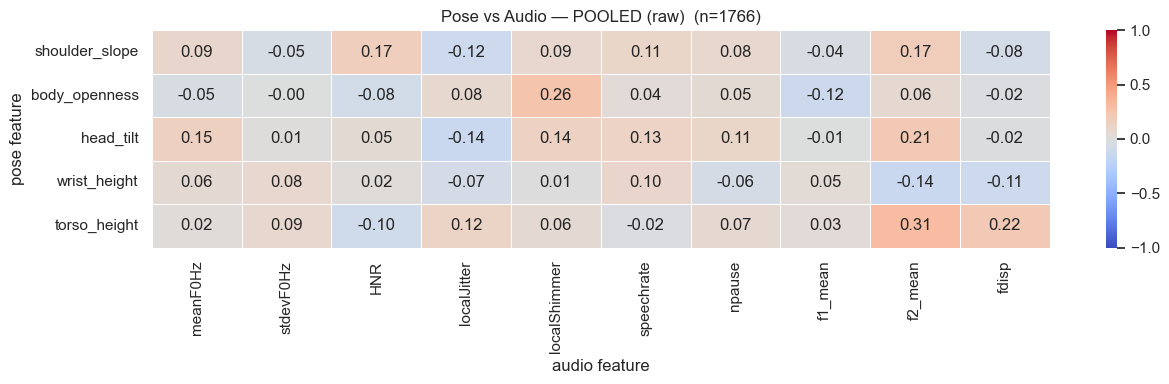

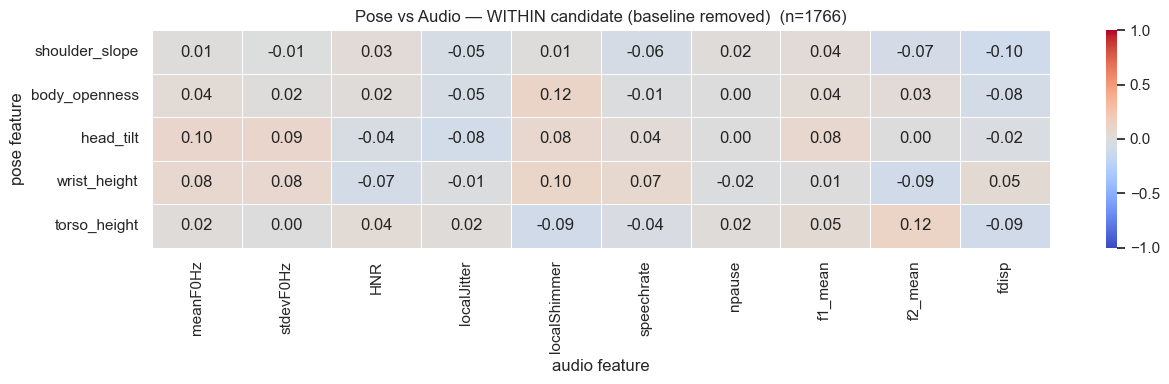

In [59]:
vp = seg_cands.dropna(subset=pose_feature_cols)
pooled = vp[pose_feature_cols + NON_REDUNDANT].corr('spearman').loc[pose_feature_cols, NON_REDUNDANT]

cen = vp.copy()
for col in pose_feature_cols + NON_REDUNDANT:
    cen[col] = vp[col] - vp.groupby('final_name')[col].transform('mean')
within = cen[pose_feature_cols + NON_REDUNDANT].corr('spearman').loc[pose_feature_cols, NON_REDUNDANT]

for mat, ttl in [(pooled, 'POOLED (raw)'), (within, 'WITHIN candidate (baseline removed)')]:
    plt.figure(figsize=(13, 4))
    sns.heatmap(mat, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=.5)
    plt.title(f'Pose vs Audio — {ttl}  (n={len(vp)})')
    plt.xlabel('audio feature'); plt.ylabel('pose feature')
    plt.tight_layout(); plt.show()

---
# Part III — New findings 

These analyses require aggregating across all 28 debates and cannot be done
on a single video. They are the **headline Part 3 results**.

## III.1 — Per-candidate emotion profile

Who is consistently **angry, surprised, sad** across all their debates?
For each candidate we compute their mean emotion probability profile (averaged over
all segments from all their debates). 

In [ ]:
emotion_profile = seg_cands.groupby('final_name')[emotion_cols].mean()
# rename columns: prob_Anger -> Anger
emotion_profile.columns = [c.replace('prob_','') for c in emotion_profile.columns]
emotion_profile = emotion_profile.reindex(CANDIDATES)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(emotion_profile, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size':9})
ax.set_title('Mean emotion probability per candidate across all debates\n'
             '(higher = that emotion appears more often while this candidate speaks)', fontsize=12)
ax.set_ylabel('Candidate')
plt.tight_layout(); plt.show()

print('Dominant emotion per candidate:')
print(emotion_profile.idxmax(axis=1).to_string())
print()
print('Least common emotion per candidate:')
print(emotion_profile.idxmin(axis=1).to_string())

In [ ]:
# Radar / spider chart of emotion profiles per candidate
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

emotions = [c.replace('prob_','') for c in emotion_cols]
N = len(emotions)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

fig, axes = plt.subplots(2, 4, figsize=(20, 10), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

for ax, cand in zip(axes, CANDIDATES):
    if cand not in emotion_profile.index:
        ax.axis('off'); continue
    vals = list(emotion_profile.loc[cand].values) + [emotion_profile.loc[cand].values[0]]
    ax.plot(angles, vals, 'o-', lw=2, color=CAND_COLOR.get(cand,'grey'))
    ax.fill(angles, vals, alpha=0.2, color=CAND_COLOR.get(cand,'grey'))
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(emotions, fontsize=9)
    ax.set_title(cand.replace('_',' '), fontsize=11, pad=15,
                 color=CAND_COLOR.get(cand,'grey'), fontweight='bold')
    ax.set_ylim(0, emotion_profile.values.max()*1.1)

for ax in axes[len(CANDIDATES):]: ax.axis('off')
plt.suptitle('Emotion profile per candidate — radar chart', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## III.2 — Poll correlation

Can we predict a candidate's poll standing from their acoustic and emotional features?
We align each debate to the nearest poll in `polls_timeline.pkl` and compute
Spearman correlations between candidate-level features and their poll percentage.

In [ ]:
polls = pd.read_pickle(os.path.join(FEATURES_DIR, 'polls_timeline.pkl'))

MONTHS_MAP = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
              'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}

def parse_date_str(s):
    parts = str(s).split('_')
    if len(parts)!=2: return None
    mon = MONTHS_MAP.get(parts[0])
    if not mon: return None
    yr = 2025 if mon>=9 else 2026
    return pd.Timestamp(yr, mon, int(parts[1]))

def parse_video_date(v):
    m = re.search(r'(January|February|March|April|May|June|July|August|'
                  r'September|October|November|December)_(\d+)', v)
    if not m: return None
    mon = MONTHS_MAP[m.group(1)]; day = int(m.group(2))
    yr = 2025 if mon>=10 else 2026
    return pd.Timestamp(yr, mon, day)

polls['poll_date'] = polls['date'].apply(parse_date_str)
polls = polls.dropna(subset=['poll_date']).sort_values('poll_date')

# Per-debate, per-candidate: mean acoustic + emotion features
seg_all['debate_date'] = seg_all['video'].apply(parse_video_date)
feat_cols = NON_REDUNDANT + [c for c in emotion_cols if c in seg_all.columns]

debate_cand_feats = (seg_all[seg_all['final_name'].isin(CANDIDATES)]
                     .groupby(['video','final_name','debate_date'])[feat_cols]
                     .mean().reset_index())

# For each debate, find the nearest poll
def nearest_poll_value(cand, debate_dt):
    if debate_dt is None or cand not in polls.columns: return np.nan
    diffs = (polls['poll_date'] - debate_dt).abs()
    idx = diffs.idxmin()
    return polls.loc[idx, cand]

debate_cand_feats['poll_pct'] = debate_cand_feats.apply(
    lambda r: nearest_poll_value(r['final_name'], r['debate_date']), axis=1)

print(f'Rows for correlation: {len(debate_cand_feats.dropna(subset=["poll_pct"]))}')
display(debate_cand_feats.head())

In [ ]:
# Spearman correlation: acoustic/emotion features vs poll percentage
valid = debate_cand_feats.dropna(subset=['poll_pct'])
poll_corr = {}
for f in feat_cols:
    d = valid[[f,'poll_pct']].dropna()
    if len(d)<10: continue
    rho,p = spearmanr(d[f], d['poll_pct'])
    poll_corr[f] = {'rho':rho,'p':p,'n':len(d)}

poll_corr_df = (pd.DataFrame(poll_corr).T
                .sort_values('rho', key=abs, ascending=False))
print('Feature correlations with poll standing:')
display(poll_corr_df.round(3).head(15))

# Bar chart of top correlations
top = poll_corr_df.dropna().head(12)
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#2ca02c' if r>0 else '#d62728' for r in top['rho']]
bars = ax.barh(top.index, top['rho'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
for bar, (_, row) in zip(bars, top.iterrows()):
    sig = '*' if row['p']<0.05 else ''
    ax.text(row['rho'], bar.get_y()+bar.get_height()/2,
            f' {sig}', va='center', fontsize=10, color='black')
ax.set_xlabel('Spearman ρ with poll %  (* = p<0.05)')
ax.set_title('Which acoustic/emotion features correlate with poll standing?\n'
             '(positive = feature is higher for better-polling candidates)')
plt.tight_layout(); plt.show()

## III.3 — Candidate-opponent effect

Does a candidate **sound or look different** depending on who they are debating?
We build a candidate × opponent matrix for key features: if Candidate A's pitch
is systematically higher when debating Candidate B than C, that is an opponent effect.
This is only testable across multiple debates.

In [ ]:
# Build candidate × opponent feature means
opp_rows = []
for v in debate_videos:
    cA,cB = extract_candidates(v)
    if cA is None: continue
    for cand,opp in [(cA,cB),(cB,cA)]:
        segs = seg_all[(seg_all['video']==v) & (seg_all['final_name']==cand)]
        if len(segs)==0: continue
        row = {'candidate':cand,'opponent':opp,'n_segs':len(segs)}
        row.update(segs[NON_REDUNDANT].mean().to_dict())
        if emotion_cols:
            row.update(segs[emotion_cols].mean().to_dict())
        opp_rows.append(row)

opp_df = pd.DataFrame(opp_rows)
print(f'Candidate-opponent records: {len(opp_df)}')

# For each candidate: show how pitch and speechrate vary by opponent
SHOW_FEATS = ['meanF0Hz','speechrate','HNR']
fig, axes = plt.subplots(1, len(SHOW_FEATS), figsize=(18, 6))
for ax, feat in zip(axes, SHOW_FEATS):
    pivot = opp_df.pivot_table(index='candidate', columns='opponent', values=feat, aggfunc='mean')
    pivot = pivot.reindex(index=CANDIDATES, columns=CANDIDATES)
    sns.heatmap(pivot.astype(float), annot=True, fmt='.1f', cmap='RdBu_r',
                center=pivot.stack().mean(), ax=ax, linewidths=0.4, cbar=False,
                annot_kws={'size':8})
    ax.set_title(f'{feat}\n(row=candidate, col=opponent)', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.suptitle('Candidate × Opponent effect: does a candidate sound different\n'
             'depending on who they debate?', fontsize=13, y=1.03)
plt.tight_layout(); plt.show()

## III.4 — Joint dimensionality reduction

PCA on the full 23-feature space (10 acoustic + 8 emotion + 5 pose) across all
candidate segments. Do the first few components separate candidates, debates,
or emotions? This reveals the most important axes of variation in the multi-modal
feature space.

In [ ]:
all_features = NON_REDUNDANT + emotion_cols + pose_feature_cols
joint = seg_cands.dropna(subset=all_features).copy()
print(f'Segments for joint PCA: {len(joint)} | Features: {len(all_features)}')

X_scaled = StandardScaler().fit_transform(joint[all_features])

# Scree plot
pca_full = PCA(random_state=42).fit(X_scaled)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_) * 100
fig, ax  = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cum_var)+1), cum_var, marker='o', ms=4)
ax.axhline(80, color='red', ls='--', lw=1, label='80% threshold')
ax.set_xlabel('Number of components'); ax.set_ylabel('Cumulative variance (%)')
ax.set_title('Scree plot — 23-feature joint space'); ax.legend()
plt.tight_layout(); plt.show()
n80 = np.argmax(cum_var>=80)+1
print(f'{n80} components explain ≥80% of variance')

In [ ]:
# 2D PCA scatter — colored by candidate, top emotion, party
X_2d = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
v1_j, v2_j = PCA(n_components=2, random_state=42).fit(X_scaled).explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# by candidate
for cand in CANDIDATES:
    mask = joint['final_name'].values == cand
    axes[0].scatter(X_2d[mask,0], X_2d[mask,1], label=cand, alpha=0.4, s=15,
                    color=CAND_COLOR.get(cand,'grey'))
axes[0].set_title('By candidate'); axes[0].legend(fontsize=7)

# by dominant emotion
for em in emotion_order:
    mask = joint['top_emotion'].values == em
    axes[1].scatter(X_2d[mask,0], X_2d[mask,1], label=em, alpha=0.4, s=15,
                    color=emotion_colors.get(em,'grey'))
axes[1].set_title('By dominant emotion'); axes[1].legend(fontsize=7)

# by party
parties_j = joint['final_name'].map({c: seg_all[seg_all['final_name']==c]['final_name'].iloc[0]
                                      if len(seg_all[seg_all['final_name']==c])>0
                                      else c for c in CANDIDATES})
for _, g in joint.groupby('final_name'):
    mask = joint['final_name'].values == g['final_name'].iloc[0]
    axes[2].scatter(X_2d[mask,0], X_2d[mask,1], label=g['final_name'].iloc[0],
                    alpha=0.35, s=12, color=CAND_COLOR.get(g['final_name'].iloc[0],'grey'))
axes[2].set_title('By candidate (for party reference)'); axes[2].legend(fontsize=7)

for ax in axes:
    ax.set_xlabel(f'PC1 ({v1_j:.1f}%)'); ax.set_ylabel(f'PC2 ({v2_j:.1f}%)')
plt.suptitle('Joint PCA — 23-feature space (acoustic + emotion + pose)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
# Feature loadings on PC1 and PC2 — what drives the main axes of variation?
pca2 = PCA(n_components=2, random_state=42).fit(X_scaled)
loadings = pd.DataFrame(pca2.components_.T, index=all_features, columns=['PC1','PC2'])
loadings['abs_pc1'] = loadings['PC1'].abs()
loadings['abs_pc2'] = loadings['PC2'].abs()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, pc in zip(axes, ['PC1','PC2']):
    top = loadings[pc].abs().nlargest(10)
    colors = ['#2ca02c' if loadings.loc[f,pc]>0 else '#d62728' for f in top.index]
    ax.barh(top.index[::-1], loadings.loc[top.index[::-1], pc].values,
            color=colors[::-1], edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel(f'Loading on {pc}')
    ax.set_title(f'Top 10 features driving {pc}\n(green=positive, red=negative loading)')
plt.tight_layout(); plt.show()